# HAI P1 Surrogate Model — A100 Version
## GRU Controller-Plant Architecture with HAIEnd Integration

**Improvements over NARX version:**
- GRU encoder-decoder replaces NARX (handles hidden state, reduces collinearity)
- Scheduled sampling during training (rollout stability)
- CC classifier-regressor split (handles binary switching)
- HAIEnd internal columns as plant auxiliaries (richer dynamics)
- Target: 15-30 min rollout (was 5 min)

## Cell 1 — Config & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from scipy.stats import ks_2samp, probplot
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score
import warnings, os, time, gc
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
from enum import Enum

warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================
# LOOP DEFINITIONS — Verified against actual HAI 23.05 columns
# ============================================================

@dataclass
class LoopConfig:
    name: str
    sp: str; cv: str; cv_fb: Optional[str]; pv: str
    sp_range: Tuple[float, float]; pv_range: Tuple[float, float]
    description: str = ""

# Keep x1001_05 as PC SP (NOT x1001_15 — that must stay as plant auxiliary)
LOOPS: Dict[str, LoopConfig] = {
    'PC': LoopConfig('Pressure Control',
        sp='x1001_05_SETPOINT_OUT', cv='P1_PCV01D', cv_fb='P1_PCV01Z', pv='P1_PIT01',
        sp_range=(0.1,0.3), pv_range=(0,10)),
    'LC': LoopConfig('Level Control',
        sp='x1002_07_SETPOINT_OUT', cv='P1_LCV01D', cv_fb='P1_LCV01Z', pv='P1_LIT01',
        sp_range=(300,500), pv_range=(0,720)),
    'FC': LoopConfig('Flow Control',
        sp='x1002_08_SETPOINT_OUT', cv='P1_FCV03D', cv_fb='P1_FCV03Z', pv='P1_FT03Z',
        sp_range=(900,1100), pv_range=(0,2500)),
    'TC': LoopConfig('Temperature Control',
        sp='x1003_18_SETPOINT_OUT', cv='P1_FCV01D', cv_fb='P1_FCV01Z', pv='P1_TIT01',
        sp_range=(25,30), pv_range=(0,50)),
    'CC': LoopConfig('Cooling Control',
        sp='P1_PP04SP', cv='P1_PP04', cv_fb=None, pv='P1_TIT03',
        sp_range=(26,30), pv_range=(0,50)),
}

SP_COLS = [LOOPS[k].sp for k in LOOPS]
CV_COLS = [LOOPS[k].cv for k in LOOPS]
PV_COLS = [LOOPS[k].pv for k in LOOPS]

# HAI auxiliary signals (from SCADA)
HAI_AUX = [
    'P1_FCV02D', 'P1_FCV02Z', 'P1_PCV02D', 'P1_PCV02Z',
    'P1_FT01', 'P1_FT01Z', 'P1_FT02', 'P1_FT02Z', 'P1_FT03',
    'P1_PIT02', 'P1_TIT02', 'P1_PP04D',
    'x1001_15_ASSIGN_OUT',  # CRITICAL: PC scaled setpoint, must stay in plant
    'x1003_10_SETPOINT_OUT', 'x1003_24_SUM_OUT',
]

# HAIEnd columns to include (non-constant, informative internals)
HAIEND_COLS = [
    # PC internals
    '1001.13-OUT', '1001.14-OUT', '1001.15-OUT',
    '1001.16-OUT', '1001.17-OUT', '1001.20-OUT',
    # LC internals
    '1002.9-OUT', '1002.20-OUT', '1002.21-OUT', '1002.30-OUT', '1002.31-OUT',
    # FC/TC internals
    '1003.5-OUT', '1003.10-OUT', '1003.11-OUT', '1003.17-OUT',
    '1003.23-OUT', '1003.24-OUT', '1003.25-OUT', '1003.26-OUT',
    '1003.29-OUT', '1003.30-OUT',
    # CC internals
    '1020.13-OUT', '1020.14-OUT', '1020.15-OUT',
    '1020.18-OUT', '1020.20-OUT',
    # Physical sensors
    'DM-PP04-D', 'DM-PP04-AO',
    'DM-TWIT-04', 'DM-TWIT-05',
    'DM-AIT-DO', 'DM-AIT-PH',
    'GATEOPEN',
    # Flow sensors (HAIEnd versions)
    'DM-FT01Z', 'DM-FT02Z', 'DM-FT03Z',
]

# Physical output limits
CV_LIMITS = {'PC':(0,100), 'LC':(0,100), 'FC':(0,100), 'TC':(0,100), 'CC':(0,50)}
PV_LIMITS = {'P1_PIT01':(0,10), 'P1_LIT01':(0,720), 'P1_FT03Z':(0,2500),
             'P1_TIT01':(0,50), 'P1_TIT03':(0,50)}

@dataclass
class ModelConfig:
    # GRU architecture
    ctrl_hidden: int = 64
    ctrl_layers: int = 2
    plant_hidden: int = 256
    plant_layers: int = 2
    # Training
    seq_len: int = 300          # 5-min sequences for training
    batch_size: int = 256
    lr: float = 1e-3
    max_epochs: int = 150
    patience: int = 20
    # Scheduled sampling
    ss_start_epoch: int = 10    # Start mixing predictions at epoch 10
    ss_end_epoch: int = 100     # Reach max mixing at epoch 100
    ss_max_ratio: float = 0.5   # Max 50% predicted inputs
    # CC classifier
    cc_threshold: float = 0.5   # PP04 > 0.5 = pump on
    # Validation
    rollout_horizons: List[int] = field(default_factory=lambda: [300, 600, 900, 1800])
    nrmse_threshold: float = 0.10

CONFIG = ModelConfig()

print("Config ready. Target rollout horizons:", CONFIG.rollout_horizons)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Config ready. Target rollout horizons: [300, 600, 900, 1800]


## Cell 2 — Data Loading (HAI + HAIEnd Merge)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

HAI_DIR = '/content/drive/MyDrive/HAI_GNN/data/raw/hai-23.05/'
END_DIR = '/content/drive/MyDrive/HAI_GNN/data/raw/haiend-23.05/'

def load_and_merge(hai_dir, end_dir, file_idx_list, label='fit'):
    """Load HAI + HAIEnd files, merge by index (NOT timestamp)."""
    frames = []
    for i in file_idx_list:
        print(f"  Loading train{i}...")
        hai = pd.read_csv(os.path.join(hai_dir, f'hai-train{i}.csv'))
        end = pd.read_csv(os.path.join(end_dir, f'end-train{i}.csv'))

        # Merge by index — drop HAIEnd timestamp
        end = end.drop(columns=['Timestamp'], errors='ignore')

        # Only keep HAIEnd columns we need
        end_keep = [c for c in HAIEND_COLS if c in end.columns]
        end = end[end_keep]

        assert len(hai) == len(end), f"Row mismatch: HAI={len(hai)}, END={len(end)}"
        merged = pd.concat([hai, end], axis=1)
        merged['_source'] = f'train{i}'
        frames.append(merged)
        print(f"    HAI: {hai.shape}, END kept: {len(end_keep)}, merged: {merged.shape}")

    df = pd.concat(frames, ignore_index=True)
    print(f"  {label}: {df.shape[0]:,} rows × {df.shape[1]} cols ({df.shape[0]/3600:.1f}h)")
    return df

print("=== Loading and merging ===")
print("\nFitting set:")
df_fit = load_and_merge(HAI_DIR, END_DIR, [1,2,3], 'fit')
print("\nValidation set:")
df_val = load_and_merge(HAI_DIR, END_DIR, [4], 'val')

# Verify required columns
all_needed = set(SP_COLS + CV_COLS + PV_COLS + HAI_AUX + HAIEND_COLS)
available = set(df_fit.columns)
missing = all_needed - available
found_end = [c for c in HAIEND_COLS if c in available]

print(f"\nRequired: {len(all_needed)}, Found: {len(all_needed - missing)}, Missing: {len(missing)}")
if missing: print(f"  Missing: {missing}")
print(f"HAIEnd columns loaded: {len(found_end)}")

# Filter auxiliaries to available + non-constant
print("\n--- Dropping constants ---")
all_aux = [c for c in HAI_AUX + HAIEND_COLS if c in available]
constant_cols = []
for col in all_aux:
    if df_fit[col].dtype not in ['float64','float32','int64']: continue
    if df_fit[col].std() < 1e-10:
        constant_cols.append(col)
        print(f"  Constant: {col} = {df_fit[col].iloc[0]}")

PLANT_AUX = [c for c in all_aux if c not in constant_cols and c not in SP_COLS]
print(f"\nPlant auxiliary signals: {len(PLANT_AUX)}")
for c in PLANT_AUX:
    print(f"  {c}: [{df_fit[c].min():.3f}, {df_fit[c].max():.3f}]")

# SP-PV tracking
print("\n--- SP-PV Tracking ---")
for k, lp in LOOPS.items():
    sp_m, pv_m = df_fit[lp.sp].mean(), df_fit[lp.pv].mean()
    corr = df_fit[lp.sp].corr(df_fit[lp.pv])
    print(f"  {k}: SP={sp_m:.2f}, PV={pv_m:.2f}, corr={corr:.3f}")

# NaN check
nans = df_fit[list(all_needed & available)].isnull().sum().sum()
print(f"\n{'✓ No NaNs' if nans==0 else f'⚠ {nans} NaNs'}")
print(f"Memory: fit={df_fit.memory_usage(deep=True).sum()/1e6:.0f}MB, "
      f"val={df_val.memory_usage(deep=True).sum()/1e6:.0f}MB")

Mounted at /content/drive
=== Loading and merging ===

Fitting set:
  Loading train1...
    HAI: (280800, 87), END kept: 36, merged: (280800, 124)
  Loading train2...
    HAI: (291600, 87), END kept: 36, merged: (291600, 124)
  Loading train3...
    HAI: (126000, 87), END kept: 36, merged: (126000, 124)
  fit: 698,400 rows × 124 cols (194.0h)

Validation set:
  Loading train4...
    HAI: (198000, 87), END kept: 36, merged: (198000, 124)
  val: 198,000 rows × 124 cols (55.0h)

Required: 66, Found: 66, Missing: 0
HAIEnd columns loaded: 36

--- Dropping constants ---

Plant auxiliary signals: 51
  P1_FCV02D: [15.000, 100.000]
  P1_FCV02Z: [12.292, 97.597]
  P1_PCV02D: [12.000, 17.174]
  P1_PCV02Z: [11.667, 16.298]
  P1_FT01: [0.801, 198.784]
  P1_FT01Z: [4.171, 892.227]
  P1_FT02: [1.183, 2506.676]
  P1_FT02Z: [6.157, 3190.000]
  P1_FT03: [217.094, 282.707]
  P1_PIT02: [0.312, 1.543]
  P1_TIT02: [32.523, 39.618]
  P1_PP04D: [0.000, 1.000]
  x1001_15_ASSIGN_OUT: [0.778, 1.598]
  x1003_10_S

## Cell 3 — Normalization & Signal Preparation

In [3]:
# Define the exact signal sets for controller and plant models

# Controller inputs per loop: (SP, PV, CV_fb) → CV
CTRL_INPUTS = {}
for ln, lp in LOOPS.items():
    cols = [lp.sp, lp.pv]
    if lp.cv_fb: cols.append(lp.cv_fb)
    CTRL_INPUTS[ln] = cols

# Plant inputs: all CVs + all auxiliaries (NO setpoints!)
PLANT_IN_COLS = CV_COLS + [c for c in PLANT_AUX if c not in SP_COLS]
# Verify no SP leakage
for c in PLANT_IN_COLS:
    assert c not in SP_COLS, f"SP leak: {c}"
print(f"Plant inputs: {len(PLANT_IN_COLS)} signals (0 setpoints ✓)")

# Normalize all signals
print("\nFitting scalers...")
ctrl_scalers = {}
for ln in LOOPS:
    cols = CTRL_INPUTS[ln] + [LOOPS[ln].cv]
    sc = StandardScaler()
    sc.fit(df_fit[cols].values)
    sc.scale_ = np.clip(sc.scale_, 1e-6, None)
    ctrl_scalers[ln] = {'scaler': sc, 'cols': cols}

plant_all_cols = PLANT_IN_COLS + PV_COLS  # inputs + outputs together for scaling
plant_scaler = StandardScaler()
plant_scaler.fit(df_fit[plant_all_cols].values)
plant_scaler.scale_ = np.clip(plant_scaler.scale_, 1e-6, None)

print(f"  Controller scalers: {len(ctrl_scalers)} loops")
print(f"  Plant scaler: {len(plant_all_cols)} signals")

# Pre-scale the full datasets for faster sequence extraction
print("Pre-scaling datasets...")

ctrl_scaled = {}
for ln in LOOPS:
    cols = ctrl_scalers[ln]['cols']
    sc = ctrl_scalers[ln]['scaler']
    ctrl_scaled[ln] = {
        'fit': sc.transform(df_fit[cols].values).astype(np.float32),
        'val': sc.transform(df_val[cols].values).astype(np.float32),
    }

plant_fit_scaled = plant_scaler.transform(df_fit[plant_all_cols].values).astype(np.float32)
plant_val_scaled = plant_scaler.transform(df_val[plant_all_cols].values).astype(np.float32)

n_plant_in = len(PLANT_IN_COLS)
n_pv = len(PV_COLS)

print(f"  Plant: input_dim={n_plant_in}, output_dim={n_pv}")
print("✓ All data pre-scaled")

Plant inputs: 56 signals (0 setpoints ✓)

Fitting scalers...
  Controller scalers: 5 loops
  Plant scaler: 61 signals
Pre-scaling datasets...
  Plant: input_dim=56, output_dim=5
✓ All data pre-scaled


## Cell 4 — GRU Model Definitions

In [4]:
class GRUController(nn.Module):
    """Per-loop GRU controller: (SP, PV, CV_fb) sequence → CV."""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers,
                          batch_first=True, dropout=dropout if num_layers>1 else 0)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, h=None):
        # x: (batch, seq_len, input_dim)
        out, h_new = self.gru(x, h)
        # Use last timestep output
        cv = self.fc(out[:, -1, :])  # (batch, 1)
        return cv.squeeze(-1), h_new

    def step(self, x_t, h):
        """Single timestep: x_t (batch, input_dim), h (layers, batch, hidden)."""
        out, h_new = self.gru(x_t.unsqueeze(1), h)
        cv = self.fc(out[:, 0, :])
        return cv.squeeze(-1), h_new


class GRUPlant(nn.Module):
    """MIMO GRU plant: (CVs + aux) sequence → PVs, with autoregressive PV feedback."""
    def __init__(self, input_dim, output_dim, hidden_dim=256, num_layers=2, dropout=0.1):
        super().__init__()
        # Input: CVs + aux + current PVs
        self.gru = nn.GRU(input_dim + output_dim, hidden_dim, num_layers,
                          batch_first=True, dropout=dropout if num_layers>1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, output_dim)
        )
        self.output_dim = output_dim

    def forward(self, x_cv, pv_init, teacher_pv=None, ss_ratio=0.0):
        """
        x_cv: (batch, seq_len, n_cv_aux) — CV + auxiliary inputs
        pv_init: (batch, output_dim) — initial PV state
        teacher_pv: (batch, seq_len, output_dim) — ground truth PVs for teacher forcing
        ss_ratio: scheduled sampling ratio (0=full teacher, 1=full autoregressive)
        """
        batch, seq_len, _ = x_cv.shape
        h = None
        pv_current = pv_init
        outputs = []

        for t in range(seq_len):
            # Concatenate CV inputs with current PV
            x_t = torch.cat([x_cv[:, t, :], pv_current], dim=-1).unsqueeze(1)
            out, h = self.gru(x_t, h)
            pv_pred = self.fc(out[:, 0, :])  # (batch, output_dim)
            outputs.append(pv_pred)

            # Scheduled sampling: use prediction or teacher
            if teacher_pv is not None and t < seq_len - 1:
                use_pred = (torch.rand(batch, device=x_cv.device) < ss_ratio).float().unsqueeze(-1)
                pv_current = use_pred * pv_pred.detach() + (1 - use_pred) * teacher_pv[:, t, :]
            else:
                pv_current = pv_pred.detach()

        return torch.stack(outputs, dim=1)  # (batch, seq_len, output_dim)

    def step(self, x_cv_t, pv_current, h):
        """Single timestep for inference."""
        x_t = torch.cat([x_cv_t, pv_current], dim=-1).unsqueeze(1)
        out, h_new = self.gru(x_t, h)
        pv_pred = self.fc(out[:, 0, :])
        return pv_pred, h_new


class CCClassifierRegressor(nn.Module):
    """Two-headed CC controller: classifier (on/off) + regressor (pump speed)."""
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.1))
        self.classifier = nn.Linear(hidden_dim, 1)  # logit for P(on)
        self.regressor = nn.Linear(hidden_dim, 1)    # pump speed if on

    def forward(self, x):
        h = self.shared(x)
        logit = self.classifier(h).squeeze(-1)
        speed = self.regressor(h).squeeze(-1)
        return logit, speed

    def predict(self, x, threshold=0.5):
        logit, speed = self.forward(x)
        is_on = torch.sigmoid(logit) > threshold
        return torch.where(is_on, torch.relu(speed), torch.zeros_like(speed))


print("✓ Models defined: GRUController, GRUPlant, CCClassifierRegressor")

✓ Models defined: GRUController, GRUPlant, CCClassifierRegressor


## Cell 5 — Sequence Dataset Construction

In [5]:
class SequenceDataset(Dataset):
    """Extract fixed-length sequences from pre-scaled time series."""
    def __init__(self, data, seq_len, stride=1):
        self.data = data
        self.seq_len = seq_len
        self.stride = stride
        self.n_seqs = (len(data) - seq_len) // stride

    def __len__(self):
        return self.n_seqs

    def __getitem__(self, idx):
        start = idx * self.stride
        return torch.from_numpy(self.data[start:start + self.seq_len])


class ControllerSeqDataset(Dataset):
    """Sequences for a single controller loop."""
    def __init__(self, scaled_data, seq_len, stride=10):
        # scaled_data columns: [SP, PV, (CV_fb), CV]
        self.seq_len = seq_len
        n_cols = scaled_data.shape[1]
        self.input_dim = n_cols - 1  # all except last (CV)

        n_seqs = (len(scaled_data) - seq_len) // stride
        self.inputs = np.zeros((n_seqs, seq_len, self.input_dim), dtype=np.float32)
        self.targets = np.zeros((n_seqs, seq_len), dtype=np.float32)

        for i in range(n_seqs):
            s = i * stride
            self.inputs[i] = scaled_data[s:s+seq_len, :-1]
            self.targets[i] = scaled_data[s:s+seq_len, -1]

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return torch.from_numpy(self.inputs[idx]), torch.from_numpy(self.targets[idx])


class PlantSeqDataset(Dataset):
    """Sequences for the MIMO plant model."""
    def __init__(self, scaled_data, n_in, n_out, seq_len, stride=10):
        self.seq_len = seq_len
        n_seqs = (len(scaled_data) - seq_len - 1) // stride

        # Input: CV+aux columns
        # Output: PV columns (next step)
        self.cv_seqs = np.zeros((n_seqs, seq_len, n_in), dtype=np.float32)
        self.pv_init = np.zeros((n_seqs, n_out), dtype=np.float32)
        self.pv_teacher = np.zeros((n_seqs, seq_len, n_out), dtype=np.float32)
        self.pv_target = np.zeros((n_seqs, seq_len, n_out), dtype=np.float32)

        for i in range(n_seqs):
            s = i * stride
            self.cv_seqs[i] = scaled_data[s:s+seq_len, :n_in]
            self.pv_init[i] = scaled_data[s, n_in:]  # PV at start
            self.pv_teacher[i] = scaled_data[s:s+seq_len, n_in:]  # teacher PVs
            self.pv_target[i] = scaled_data[s+1:s+seq_len+1, n_in:]  # next-step PVs

    def __len__(self):
        return len(self.cv_seqs)

    def __getitem__(self, idx):
        return (torch.from_numpy(self.cv_seqs[idx]),
                torch.from_numpy(self.pv_init[idx]),
                torch.from_numpy(self.pv_teacher[idx]),
                torch.from_numpy(self.pv_target[idx]))


# Build datasets
print("Building sequence datasets...")
SL = CONFIG.seq_len
STRIDE = 10  # stride for sequence extraction (saves memory)

# Controller datasets
ctrl_datasets = {}
for ln in LOOPS:
    ds_fit = ControllerSeqDataset(ctrl_scaled[ln]['fit'], SL, STRIDE)
    ds_val = ControllerSeqDataset(ctrl_scaled[ln]['val'], SL, STRIDE)
    ctrl_datasets[ln] = {'fit': ds_fit, 'val': ds_val,
                          'input_dim': ds_fit.input_dim}
    print(f"  Ctrl {ln}: fit={len(ds_fit)}, val={len(ds_val)}, in_dim={ds_fit.input_dim}")

# Plant dataset
plant_ds_fit = PlantSeqDataset(plant_fit_scaled, n_plant_in, n_pv, SL, STRIDE)
plant_ds_val = PlantSeqDataset(plant_val_scaled, n_plant_in, n_pv, SL, STRIDE)
print(f"  Plant: fit={len(plant_ds_fit)}, val={len(plant_ds_val)}, "
      f"in_dim={n_plant_in}, out_dim={n_pv}")

# CC classifier dataset (flat, not sequential)
cc_pv = df_fit[['P1_TIT03', 'P1_PP04SP']].values.astype(np.float32)
cc_target = df_fit['P1_PP04'].values.astype(np.float32)
cc_is_on = (cc_target > CONFIG.cc_threshold).astype(np.float32)

cc_pv_val = df_val[['P1_TIT03', 'P1_PP04SP']].values.astype(np.float32)
cc_target_val = df_val['P1_PP04'].values.astype(np.float32)
cc_is_on_val = (cc_target_val > CONFIG.cc_threshold).astype(np.float32)

print(f"  CC classifier: fit={len(cc_pv)}, on_ratio={cc_is_on.mean():.3f}")

gc.collect()
print("✓ All datasets ready")

Building sequence datasets...
  Ctrl PC: fit=69810, val=19770, in_dim=3
  Ctrl LC: fit=69810, val=19770, in_dim=3
  Ctrl FC: fit=69810, val=19770, in_dim=3
  Ctrl TC: fit=69810, val=19770, in_dim=3
  Ctrl CC: fit=69810, val=19770, in_dim=2
  Plant: fit=69809, val=19769, in_dim=56, out_dim=5
  CC classifier: fit=698400, on_ratio=0.842
✓ All datasets ready


## Cell 6 — Train GRU Controllers (PC, LC, FC, TC)

In [6]:
def train_gru_controller(loop_name, dataset_fit, dataset_val, input_dim, config):
    """Train a GRU controller for one loop."""
    model = GRUController(input_dim, config.ctrl_hidden, config.ctrl_layers).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, config.max_epochs)
    criterion = nn.MSELoss()

    dl_fit = DataLoader(dataset_fit, batch_size=config.batch_size, shuffle=True,
                        num_workers=2, pin_memory=True)
    dl_val = DataLoader(dataset_val, batch_size=config.batch_size * 2,
                        num_workers=2, pin_memory=True)

    best_val, patience_cnt, best_state = float('inf'), 0, None

    for epoch in range(config.max_epochs):
        model.train()
        train_loss = 0
        for x_seq, y_seq in dl_fit:
            x_seq, y_seq = x_seq.to(DEVICE), y_seq.to(DEVICE)
            # Predict CV at each timestep
            out, _ = model.gru(x_seq)
            cv_pred = model.fc(out).squeeze(-1)  # (batch, seq_len)
            loss = criterion(cv_pred, y_seq)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item() * len(x_seq)
        train_loss /= len(dataset_fit)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_seq, y_seq in dl_val:
                x_seq, y_seq = x_seq.to(DEVICE), y_seq.to(DEVICE)
                out, _ = model.gru(x_seq)
                cv_pred = model.fc(out).squeeze(-1)
                val_loss += criterion(cv_pred, y_seq).item() * len(x_seq)
        val_loss /= len(dataset_val)
        scheduler.step()

        if val_loss < best_val:
            best_val = val_loss; patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1

        if epoch % 20 == 0 or patience_cnt >= config.patience:
            print(f"    ep{epoch:3d}: train={train_loss:.6f} val={val_loss:.6f} "
                  f"pat={patience_cnt} lr={scheduler.get_last_lr()[0]:.6f}")

        if patience_cnt >= config.patience:
            print(f"    Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state); model.eval()
    return model

print("=" * 60)
print("TRAINING GRU CONTROLLERS (PC, LC, FC, TC)")
print("=" * 60)

ctrl_models = {}

# Train PC, LC, FC, TC with GRU (skip CC — handled separately)
for ln in ['PC', 'LC', 'FC', 'TC']:
    print(f"\n--- {ln} ---")
    t0 = time.time()
    model = train_gru_controller(
        ln, ctrl_datasets[ln]['fit'], ctrl_datasets[ln]['val'],
        ctrl_datasets[ln]['input_dim'], CONFIG
    )
    ctrl_models[ln] = model
    print(f"    Done in {time.time()-t0:.1f}s")

# Quick validation: one-step NRMSE on last timestep of validation sequences
print("\n--- Controller Validation (one-step) ---")
ctrl_gate_results = {}
for ln in ['PC', 'LC', 'FC', 'TC']:
    model = ctrl_models[ln]
    ds = ctrl_datasets[ln]['val']
    dl = DataLoader(ds, batch_size=CONFIG.batch_size*2)
    all_pred, all_true = [], []
    with torch.no_grad():
        for x_seq, y_seq in dl:
            x_seq = x_seq.to(DEVICE)
            out, _ = model.gru(x_seq)
            cv_pred = model.fc(out).squeeze(-1)
            # Last timestep prediction
            all_pred.append(cv_pred[:, -1].cpu().numpy())
            all_true.append(y_seq[:, -1].numpy())
    pred = np.concatenate(all_pred)
    true = np.concatenate(all_true)
    # Denormalize for NRMSE
    sc = ctrl_scalers[ln]['scaler']
    cv_idx = len(ctrl_scalers[ln]['cols']) - 1
    pred_raw = pred * sc.scale_[cv_idx] + sc.mean_[cv_idx]
    true_raw = true * sc.scale_[cv_idx] + sc.mean_[cv_idx]
    nrmse = np.sqrt(np.mean((pred_raw - true_raw)**2)) / (true_raw.max() - true_raw.min())
    ctrl_gate_results[ln] = nrmse
    print(f"  {'✓' if nrmse<0.03 else '✗'} {ln}: NRMSE={nrmse:.4f}")

TRAINING GRU CONTROLLERS (PC, LC, FC, TC)

--- PC ---
    ep  0: train=0.081769 val=0.046115 pat=0 lr=0.001000
    ep 20: train=0.030574 val=0.032254 pat=0 lr=0.000952
    ep 40: train=0.028176 val=0.029832 pat=0 lr=0.000827
    ep 60: train=0.026685 val=0.030566 pat=16 lr=0.000645
    ep 64: train=0.026374 val=0.030667 pat=20 lr=0.000604
    Early stop at epoch 64
    Done in 153.7s

--- LC ---
    ep  0: train=0.058076 val=0.021721 pat=0 lr=0.001000
    ep 20: train=0.008546 val=0.007984 pat=1 lr=0.000952
    ep 40: train=0.007834 val=0.007512 pat=5 lr=0.000827
    ep 60: train=0.007375 val=0.007256 pat=1 lr=0.000645
    ep 80: train=0.007102 val=0.006994 pat=2 lr=0.000437
    ep100: train=0.006858 val=0.006867 pat=1 lr=0.000241
    ep119: train=0.006741 val=0.006917 pat=20 lr=0.000095
    Early stop at epoch 119
    Done in 272.3s

--- FC ---
    ep  0: train=0.059181 val=0.017395 pat=0 lr=0.001000
    ep 20: train=0.003528 val=0.003388 pat=0 lr=0.000952
    ep 40: train=0.002827 va

## Cell 7 — Train CC Classifier-Regressor

In [7]:
print("=" * 60)
print("TRAINING CC CLASSIFIER-REGRESSOR")
print("=" * 60)

# Scale CC inputs
cc_scaler = StandardScaler()
cc_pv_scaled = cc_scaler.fit_transform(cc_pv).astype(np.float32)
cc_pv_val_scaled = cc_scaler.transform(cc_pv_val).astype(np.float32)

cc_model = CCClassifierRegressor(input_dim=2, hidden_dim=32).to(DEVICE)
optimizer = torch.optim.Adam(cc_model.parameters(), lr=1e-3)
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

# Training
cc_train_ds = TensorDataset(
    torch.tensor(cc_pv_scaled), torch.tensor(cc_is_on), torch.tensor(cc_target))
cc_val_ds = TensorDataset(
    torch.tensor(cc_pv_val_scaled), torch.tensor(cc_is_on_val), torch.tensor(cc_target_val))
cc_train_dl = DataLoader(cc_train_ds, batch_size=2048, shuffle=True)
cc_val_dl = DataLoader(cc_val_ds, batch_size=4096)

best_val, best_state, pc = float('inf'), None, 0

for epoch in range(200):
    cc_model.train()
    for x, y_cls, y_reg in cc_train_dl:
        x, y_cls, y_reg = x.to(DEVICE), y_cls.to(DEVICE), y_reg.to(DEVICE)
        logit, speed = cc_model(x)
        # Classification loss on all samples
        loss_cls = bce(logit, y_cls)
        # Regression loss only on pump-on samples
        on_mask = y_cls > 0.5
        if on_mask.sum() > 0:
            loss_reg = mse(speed[on_mask], y_reg[on_mask])
        else:
            loss_reg = torch.tensor(0.0, device=DEVICE)
        loss = loss_cls + loss_reg
        optimizer.zero_grad(); loss.backward(); optimizer.step()

    cc_model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y_cls, y_reg in cc_val_dl:
            x, y_cls, y_reg = x.to(DEVICE), y_cls.to(DEVICE), y_reg.to(DEVICE)
            logit, speed = cc_model(x)
            loss_cls = bce(logit, y_cls)
            on_mask = y_cls > 0.5
            loss_reg = mse(speed[on_mask], y_reg[on_mask]) if on_mask.sum()>0 else torch.tensor(0.0, device=DEVICE)
            val_loss += (loss_cls + loss_reg).item() * len(x)
    val_loss /= len(cc_val_ds)

    if val_loss < best_val:
        best_val = val_loss; pc = 0
        best_state = {k: v.cpu().clone() for k, v in cc_model.state_dict().items()}
    else:
        pc += 1
    if epoch % 30 == 0:
        print(f"  ep{epoch}: val_loss={val_loss:.4f} pat={pc}")
    if pc >= 30: print(f"  Early stop at {epoch}"); break

cc_model.load_state_dict(best_state); cc_model.eval()

# Evaluate
with torch.no_grad():
    x_v = torch.tensor(cc_pv_val_scaled, device=DEVICE)
    pred_cv = cc_model.predict(x_v).cpu().numpy()
    logit, _ = cc_model(x_v)
    pred_on = (torch.sigmoid(logit) > 0.5).cpu().numpy()

cls_acc = accuracy_score(cc_is_on_val, pred_on)
on_mask = cc_is_on_val > 0.5
reg_nrmse = np.sqrt(np.mean((pred_cv[on_mask] - cc_target_val[on_mask])**2)) / (cc_target_val[on_mask].max() - cc_target_val[on_mask].min())

print(f"\n  Classifier accuracy: {cls_acc:.4f}")
print(f"  Regressor NRMSE (on samples): {reg_nrmse:.4f}")
print(f"  Overall NRMSE: {np.sqrt(np.mean((pred_cv - cc_target_val)**2)) / (cc_target_val.max()-cc_target_val.min()+1e-10):.4f}")

ctrl_models['CC'] = cc_model
ctrl_gate_results['CC'] = reg_nrmse

TRAINING CC CLASSIFIER-REGRESSOR
  ep0: val_loss=604.0240 pat=0
  ep30: val_loss=177.7678 pat=0
  ep60: val_loss=177.2229 pat=0
  ep90: val_loss=177.3914 pat=30
  Early stop at 90

  Classifier accuracy: 0.7756
  Regressor NRMSE (on samples): 0.3063
  Overall NRMSE: 0.3531


## Cell 8 — Train GRU Plant with Scheduled Sampling

TRAINING GRU PLANT (scheduled sampling)
  ep  0: train=0.038867 val=0.170358 ss=0.00 pat=0 lr=0.001000 (7.4s)
  ep  5: train=0.002079 val=0.057885 ss=0.00 pat=0 lr=0.000996 (8.1s)
  ep 10: train=0.001731 val=0.085596 ss=0.00 pat=2 lr=0.000987 (7.2s)
  ep 15: train=0.001540 val=0.045431 ss=0.03 pat=3 lr=0.000972 (147.9s)
  ep 20: train=0.001450 val=0.057963 ss=0.06 pat=3 lr=0.000952 (148.7s)
  ep 25: train=0.001346 val=0.039926 ss=0.08 pat=8 lr=0.000928 (147.8s)
  ep 30: train=0.001256 val=0.026741 ss=0.11 pat=2 lr=0.000898 (148.9s)
  ep 35: train=0.001267 val=0.048956 ss=0.14 pat=7 lr=0.000864 (148.0s)
  ep 40: train=0.001227 val=0.026014 ss=0.17 pat=12 lr=0.000827 (147.6s)
  ep 45: train=0.001204 val=0.023846 ss=0.19 pat=1 lr=0.000785 (148.1s)
  ep 50: train=0.001208 val=0.025125 ss=0.22 pat=2 lr=0.000741 (147.1s)
  ep 55: train=0.001176 val=0.021970 ss=0.25 pat=7 lr=0.000694 (148.3s)
  ep 60: train=0.001156 val=0.021949 ss=0.28 pat=12 lr=0.000645 (147.4s)
  ep 65: train=0.001138 val=

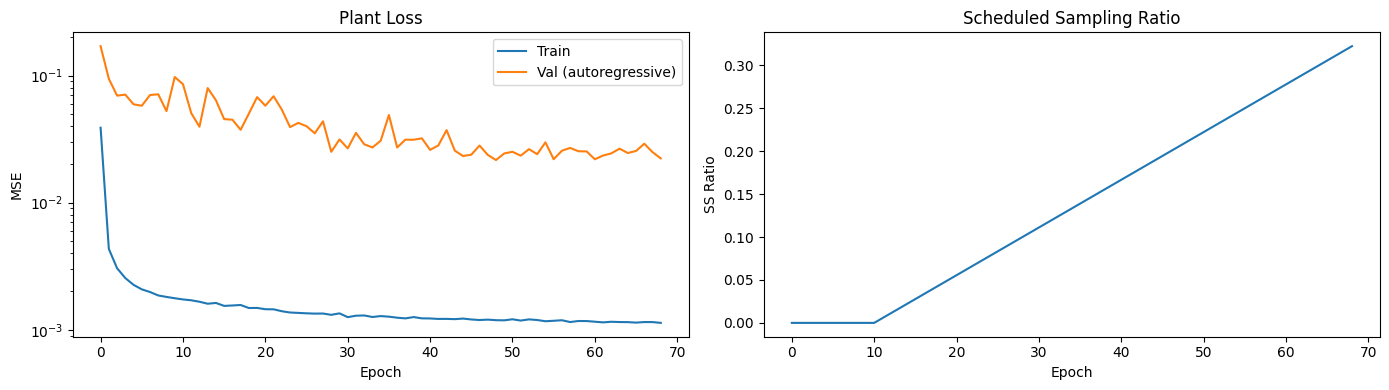


✓ Plant model trained. Best val loss: 0.021639


In [8]:
# %% [markdown]
# ## Cell 8 — Train GRU Plant with Scheduled Sampling

# %%
print("=" * 60)
print("TRAINING GRU PLANT (scheduled sampling)")
print("=" * 60)

plant_model = GRUPlant(n_plant_in, n_pv, CONFIG.plant_hidden, CONFIG.plant_layers).to(DEVICE)
optimizer = torch.optim.Adam(plant_model.parameters(), lr=CONFIG.lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, CONFIG.max_epochs)
criterion = nn.MSELoss()

dl_fit = DataLoader(plant_ds_fit, batch_size=CONFIG.batch_size, shuffle=True,
                    num_workers=2, pin_memory=True)
dl_val = DataLoader(plant_ds_val, batch_size=CONFIG.batch_size * 2,
                    num_workers=2, pin_memory=True)

def fast_teacher_forward(model, x_cv, pv_init, teacher_pv):
    """Full-sequence GRU when ss_ratio=0 (no scheduled sampling needed).
    Runs entire sequence in one vectorized call — 50-100x faster than per-step loop."""
    pv_input = torch.cat([pv_init.unsqueeze(1), teacher_pv[:, :-1, :]], dim=1)
    x_full = torch.cat([x_cv, pv_input], dim=-1)
    out, _ = model.gru(x_full)
    return model.fc(out)

best_val, patience_cnt, best_state = float('inf'), 0, None
train_losses, val_losses, ss_ratios = [], [], []

for epoch in range(CONFIG.max_epochs):
    # Scheduled sampling ratio
    if epoch < CONFIG.ss_start_epoch:
        ss_ratio = 0.0
    elif epoch >= CONFIG.ss_end_epoch:
        ss_ratio = CONFIG.ss_max_ratio
    else:
        progress = (epoch - CONFIG.ss_start_epoch) / (CONFIG.ss_end_epoch - CONFIG.ss_start_epoch)
        ss_ratio = progress * CONFIG.ss_max_ratio
    ss_ratios.append(ss_ratio)

    # Train
    plant_model.train()
    train_loss = 0
    t0 = time.time()
    for cv_seq, pv_init, pv_teacher, pv_target in dl_fit:
        cv_seq = cv_seq.to(DEVICE)
        pv_init = pv_init.to(DEVICE)
        pv_teacher = pv_teacher.to(DEVICE)
        pv_target = pv_target.to(DEVICE)

        if ss_ratio == 0.0:
            pv_pred = fast_teacher_forward(plant_model, cv_seq, pv_init, pv_teacher)
        else:
            pv_pred = plant_model(cv_seq, pv_init, pv_teacher, ss_ratio)

        loss = criterion(pv_pred, pv_target)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item() * len(cv_seq)
    train_loss /= len(plant_ds_fit)
    train_losses.append(train_loss)
    train_time = time.time() - t0

    # Validate (always full autoregressive for honest eval)
    plant_model.eval()
    val_loss = 0
    with torch.no_grad():
        for cv_seq, pv_init, pv_teacher, pv_target in dl_val:
            cv_seq = cv_seq.to(DEVICE)
            pv_init = pv_init.to(DEVICE)
            pv_target = pv_target.to(DEVICE)
            # Full autoregressive (ss_ratio=1.0, no teacher)
            pv_pred = plant_model(cv_seq, pv_init, teacher_pv=None, ss_ratio=1.0)
            val_loss += criterion(pv_pred, pv_target).item() * len(cv_seq)
    val_loss /= len(plant_ds_val)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val:
        best_val = val_loss; patience_cnt = 0
        best_state = {k: v.cpu().clone() for k, v in plant_model.state_dict().items()}
    else:
        patience_cnt += 1

    if epoch % 5 == 0 or patience_cnt >= CONFIG.patience:
        print(f"  ep{epoch:3d}: train={train_loss:.6f} val={val_loss:.6f} "
              f"ss={ss_ratio:.2f} pat={patience_cnt} lr={scheduler.get_last_lr()[0]:.6f} "
              f"({train_time:.1f}s)")

    if patience_cnt >= CONFIG.patience:
        print(f"  Early stop at epoch {epoch}")
        break

plant_model.load_state_dict(best_state); plant_model.eval()

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(train_losses, label='Train'); ax1.plot(val_losses, label='Val (autoregressive)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE'); ax1.legend(); ax1.set_title('Plant Loss')
ax1.set_yscale('log')
ax2.plot(ss_ratios); ax2.set_xlabel('Epoch'); ax2.set_ylabel('SS Ratio')
ax2.set_title('Scheduled Sampling Ratio')
plt.tight_layout(); plt.show()

print(f"\n✓ Plant model trained. Best val loss: {best_val:.6f}")

## Cell 9 — Closed-Loop Validation (Multi-Horizon)

CLOSED-LOOP VALIDATION — MULTI-HORIZON

--- Horizon: 300s (5 min), 8 windows ---
  Window 1: 12.1s
  Window 2: 12.0s
  Window 3: 11.9s
  Window 4: 12.0s
  Window 5: 12.0s
  Window 6: 12.1s
  Window 7: 12.0s
  Window 8: 12.0s

  Signal         Mean NRMSE   Std        Pass?
  ✓ P1_PIT01     0.0015       0.0002     PASS
  ✓ P1_LIT01     0.0037       0.0022     PASS
  ✓ P1_FT03Z     0.0003       0.0001     PASS
  ✓ P1_TIT01     0.0020       0.0016     PASS
  ✓ P1_TIT03     0.0044       0.0018     PASS


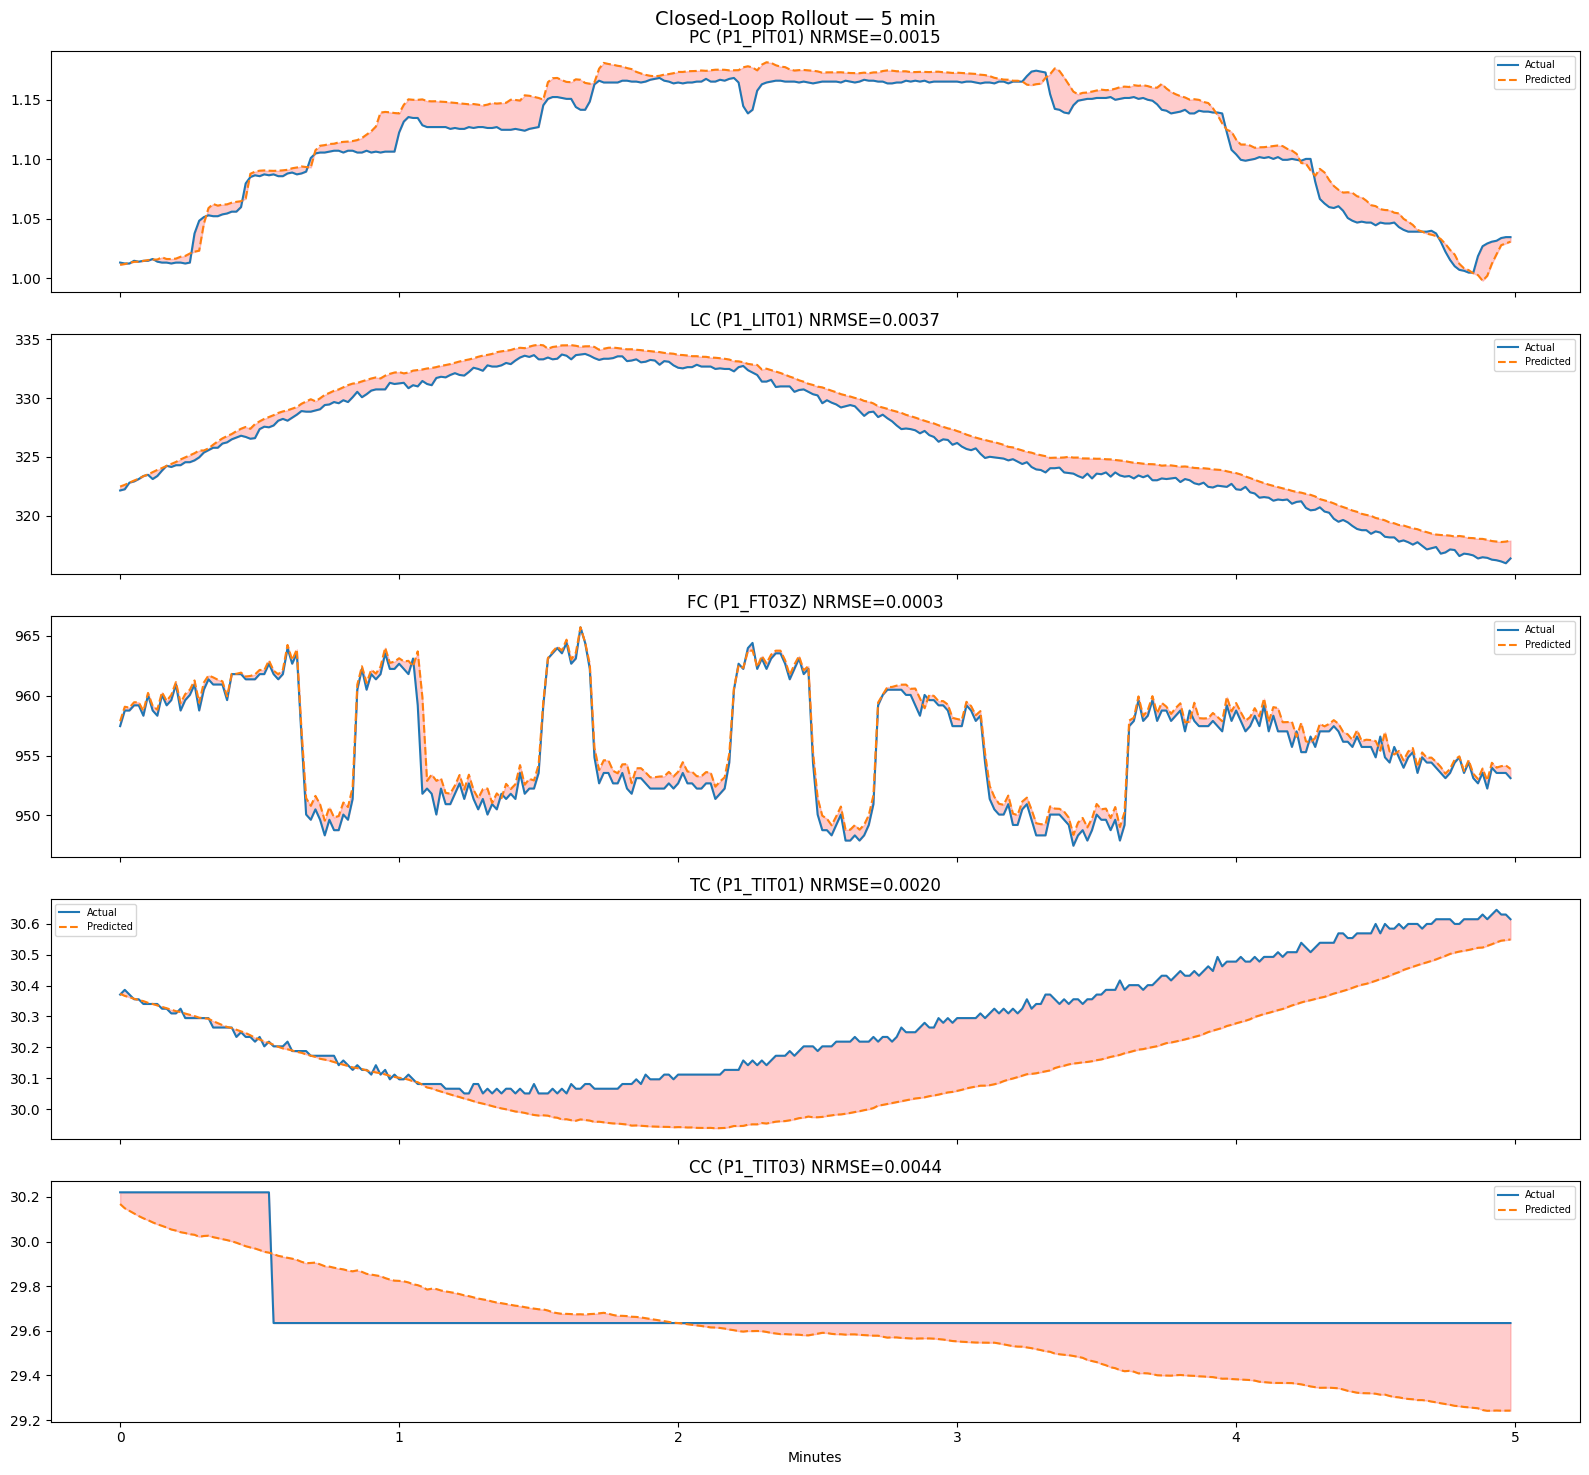


--- Horizon: 600s (10 min), 8 windows ---
  Window 1: 23.8s
  Window 2: 23.9s
  Window 3: 23.7s
  Window 4: 23.7s
  Window 5: 23.6s
  Window 6: 23.6s
  Window 7: 23.8s
  Window 8: 23.6s

  Signal         Mean NRMSE   Std        Pass?
  ✓ P1_PIT01     0.0014       0.0003     PASS
  ✓ P1_LIT01     0.0058       0.0038     PASS
  ✓ P1_FT03Z     0.0003       0.0001     PASS
  ✓ P1_TIT01     0.0029       0.0022     PASS
  ✓ P1_TIT03     0.0065       0.0031     PASS


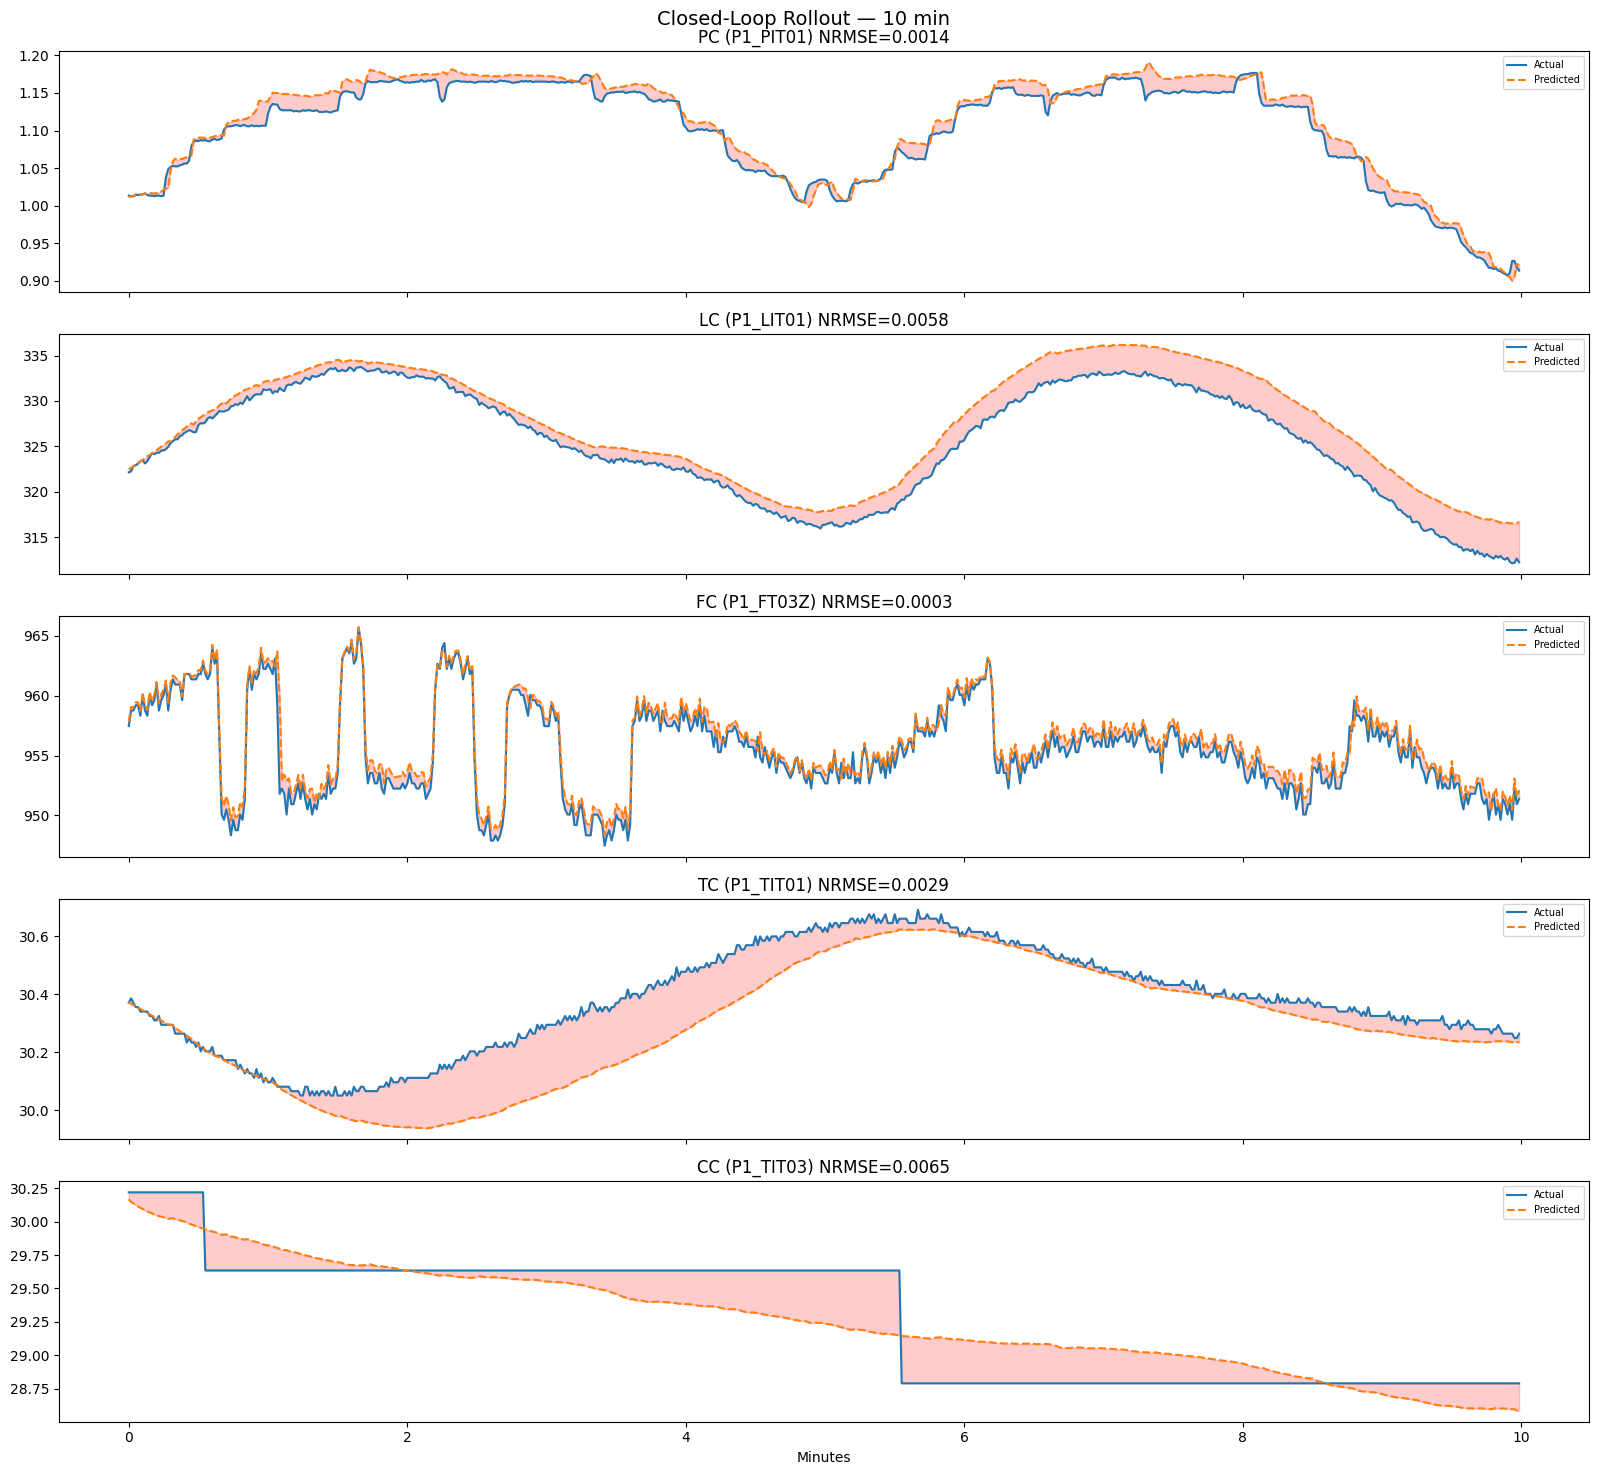


--- Horizon: 900s (15 min), 8 windows ---
  Window 1: 35.3s
  Window 2: 23.4s
  Window 3: 23.2s
  Window 4: 23.6s
  Window 5: 23.8s
  Window 6: 23.6s
  Window 7: 23.3s
  Window 8: 23.0s

  Signal         Mean NRMSE   Std        Pass?
  ✓ P1_PIT01     0.0014       0.0002     PASS
  ✓ P1_LIT01     0.0087       0.0037     PASS
  ✓ P1_FT03Z     0.0003       0.0001     PASS
  ✓ P1_TIT01     0.0036       0.0026     PASS
  ✓ P1_TIT03     0.0066       0.0030     PASS


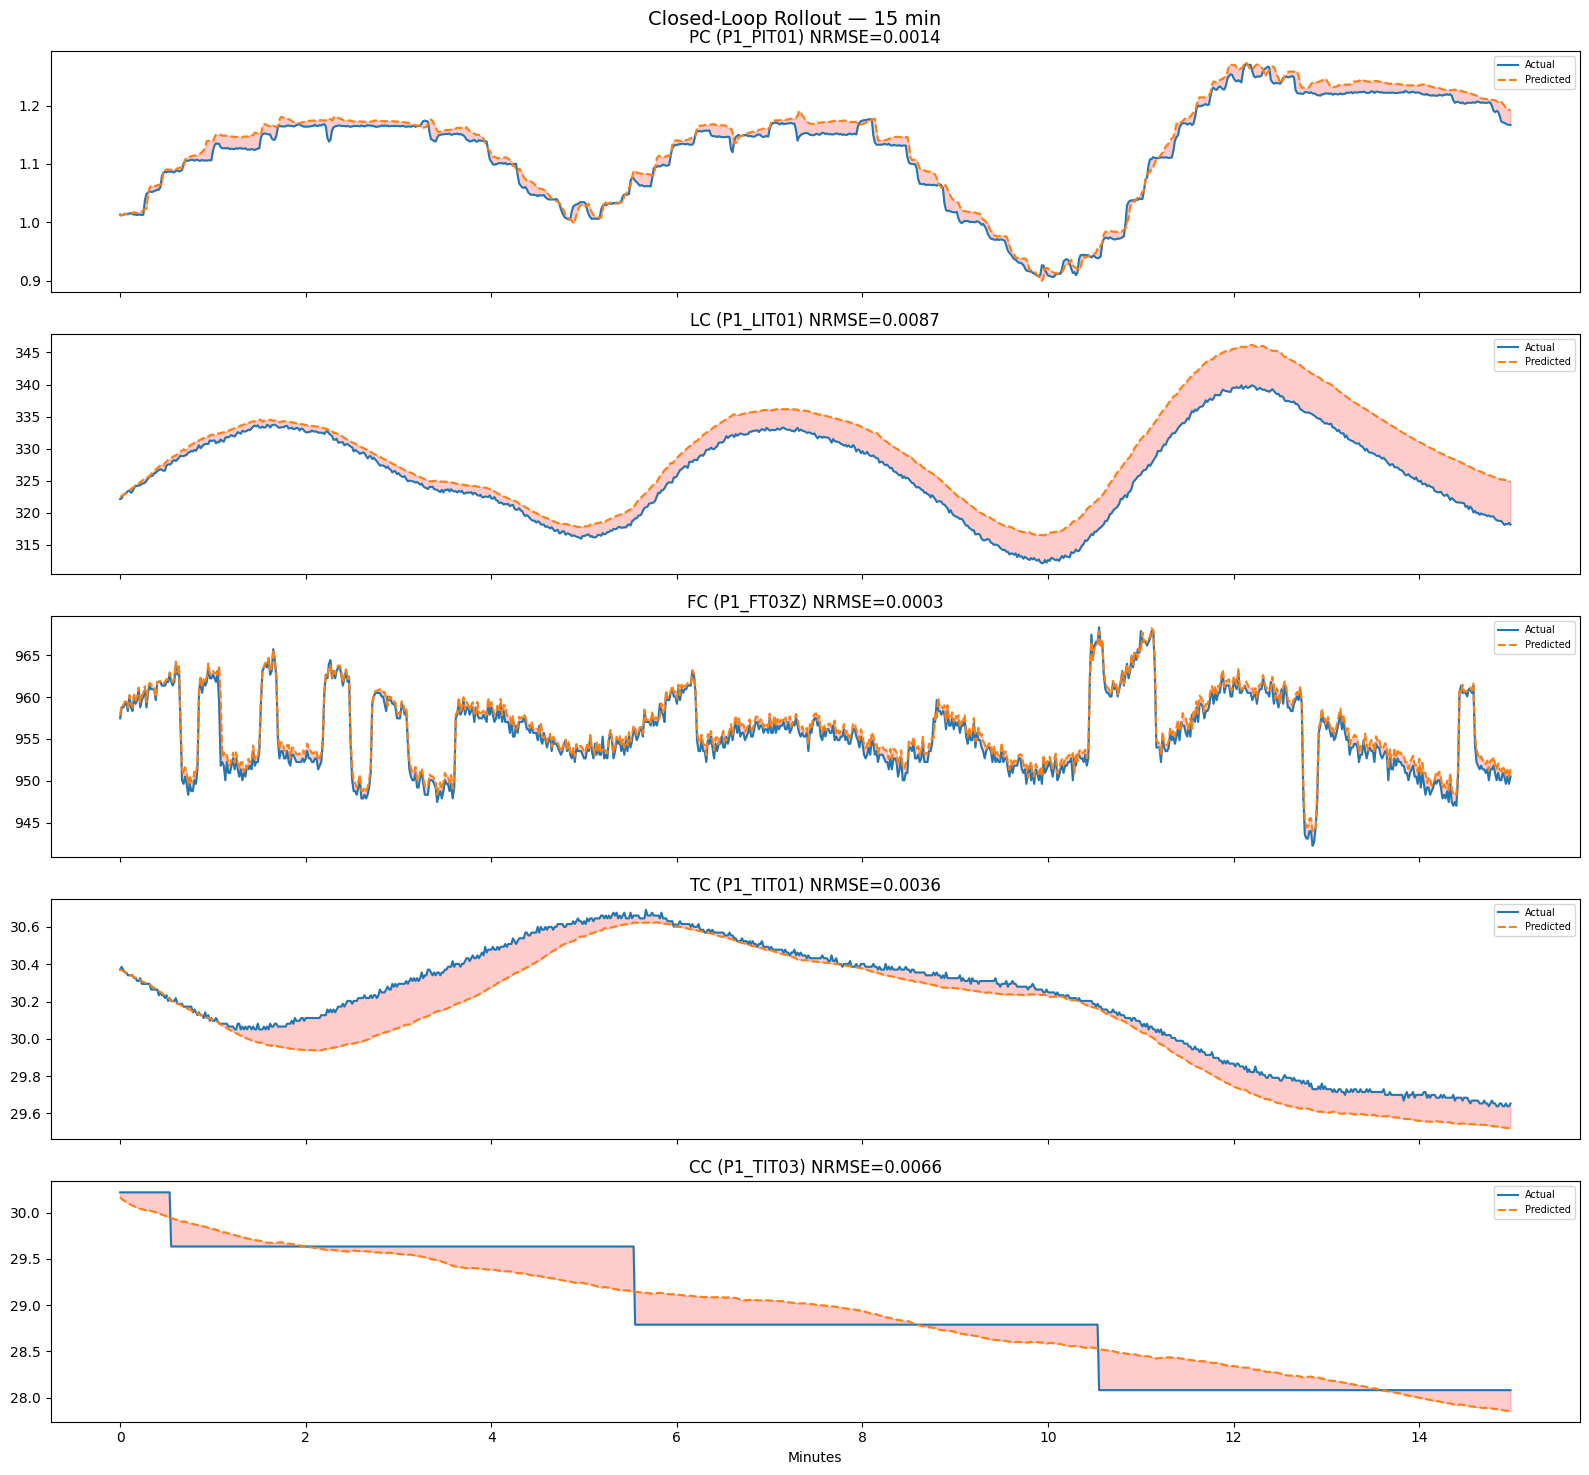


--- Horizon: 1800s (30 min), 8 windows ---
  Window 1: 57.8s
  Window 2: 46.1s
  Window 3: 45.9s
  Window 4: 46.3s
  Window 5: 46.2s
  Window 6: 46.1s
  Window 7: 46.1s
  Window 8: 46.0s

  Signal         Mean NRMSE   Std        Pass?
  ✓ P1_PIT01     0.0015       0.0001     PASS
  ✓ P1_LIT01     0.0144       0.0044     PASS
  ✓ P1_FT03Z     0.0003       0.0000     PASS
  ✓ P1_TIT01     0.0066       0.0028     PASS
  ✓ P1_TIT03     0.0077       0.0022     PASS


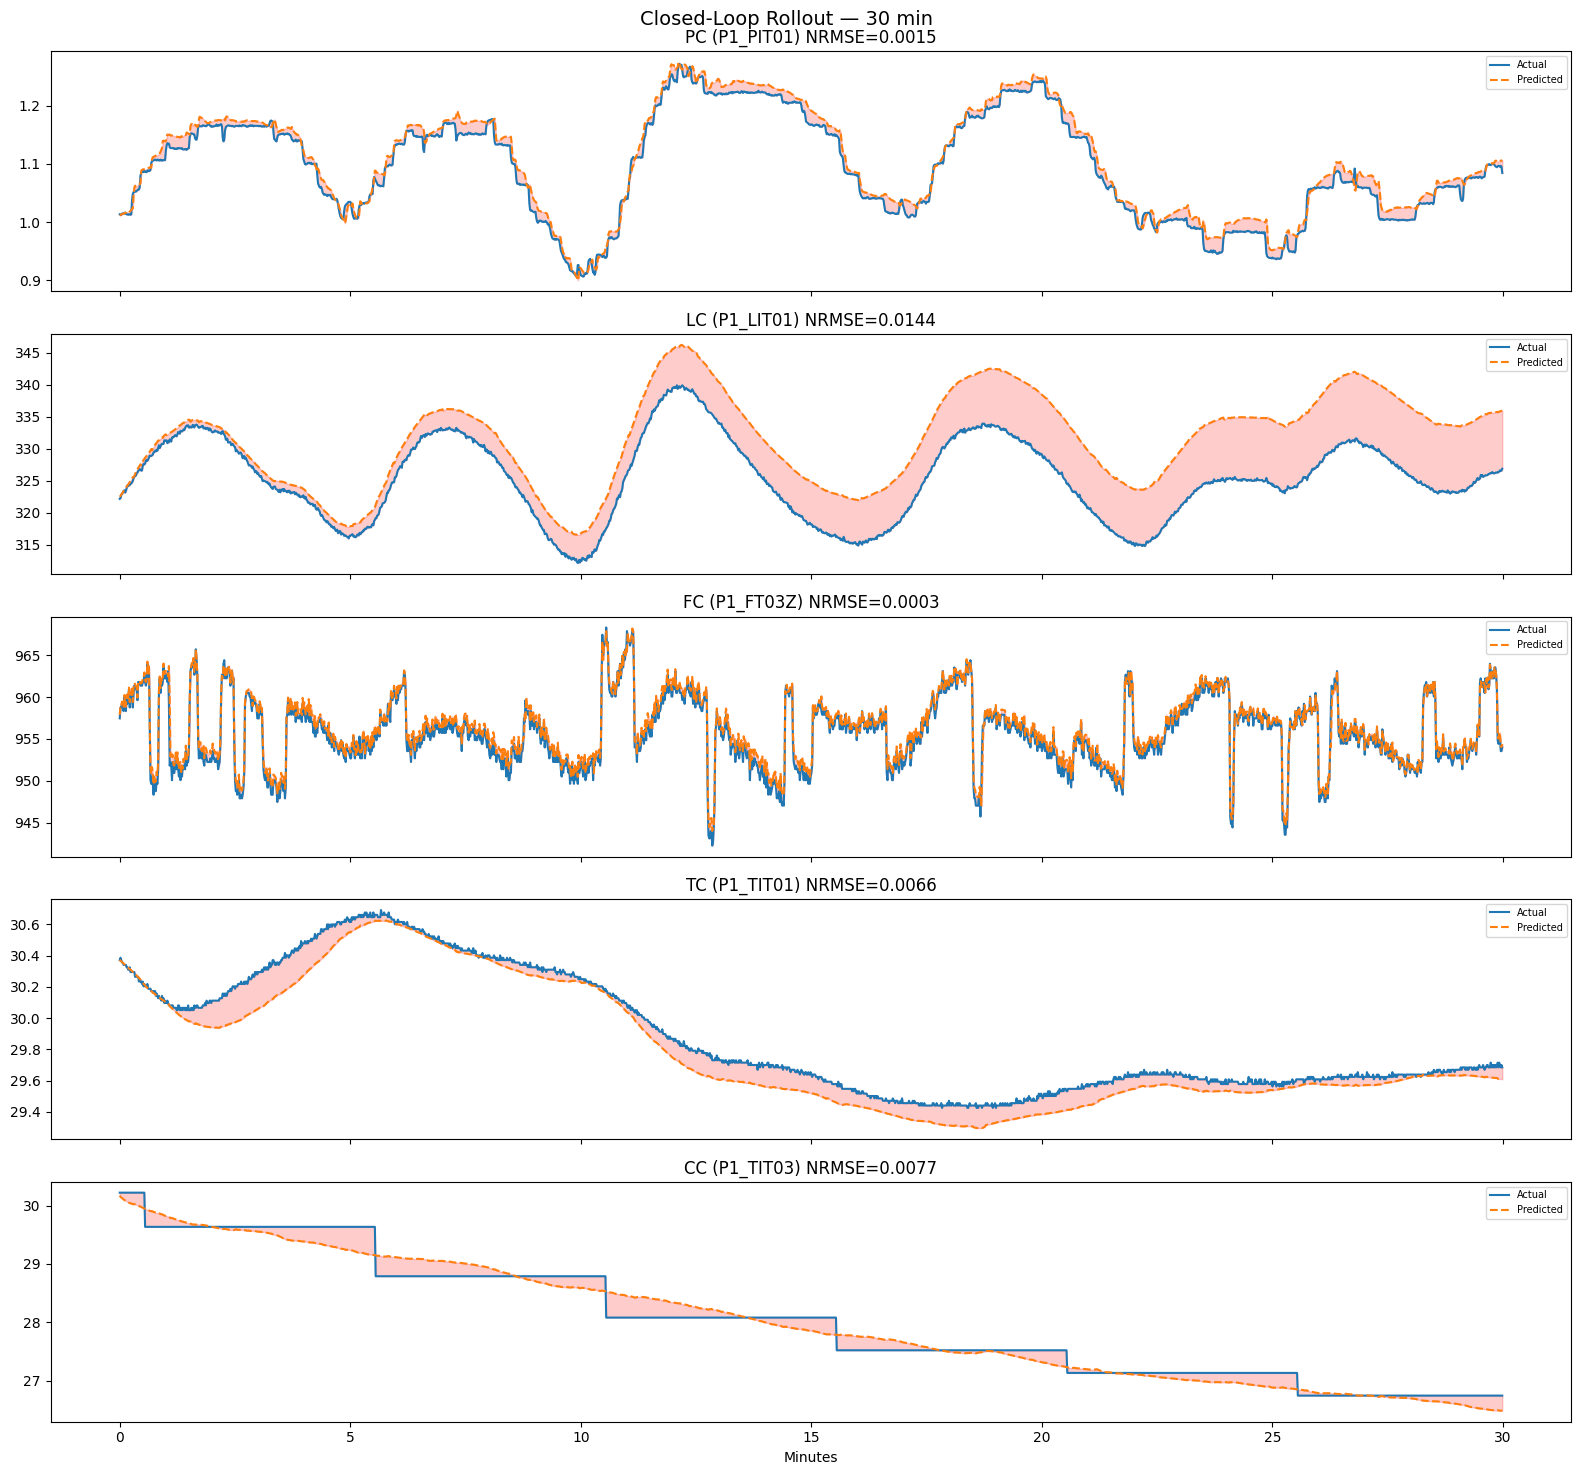


BEST PASSING HORIZON: 1800s (30 min)


In [9]:
def compute_nrmse(y_true, y_pred, sig_range=None):
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    if sig_range is None: sig_range = y_true.max() - y_true.min()
    return rmse / sig_range if sig_range > 1e-10 else 0.0

def closed_loop_rollout_gru(df, start_idx, horizon):
    """Closed-loop rollout with GRU models."""
    loop_names = list(LOOPS.keys())

    # Initialize GRU hidden states (need warmup)
    warmup = CONFIG.seq_len
    if start_idx + warmup + horizon + 1 >= len(df):
        return None, None, None, None

    # --- Warmup: run all models on real data to initialize hidden states ---
    ctrl_hiddens = {}
    for ln in ['PC', 'LC', 'FC', 'TC']:
        model = ctrl_models[ln]
        cols = ctrl_scalers[ln]['cols']
        sc = ctrl_scalers[ln]['scaler']
        warmup_data = sc.transform(df[cols].iloc[start_idx:start_idx+warmup].values)
        warmup_x = torch.tensor(warmup_data[:, :-1], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            _, h = model.gru(warmup_x)
        ctrl_hiddens[ln] = h

    # Plant warmup
    warmup_plant = plant_scaler.transform(
        df[plant_all_cols].iloc[start_idx:start_idx+warmup].values)
    warmup_cv = torch.tensor(warmup_plant[:, :n_plant_in], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    warmup_pv = torch.tensor(warmup_plant[:, n_plant_in:], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        plant_h = None
        for t in range(warmup):
            x_t = torch.cat([warmup_cv[:, t, :], warmup_pv[:, t, :]], dim=-1).unsqueeze(1)
            _, plant_h = plant_model.gru(x_t, plant_h)

    # Current PV state (scaled)
    current_pvs_raw = df[PV_COLS].iloc[start_idx + warmup].values.astype(np.float32)
    pv_offset = n_plant_in
    current_pvs_scaled = plant_scaler.transform(
        df[plant_all_cols].iloc[start_idx+warmup:start_idx+warmup+1].values)[0, pv_offset:]
    current_pvs_scaled = torch.tensor(current_pvs_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    # --- Rollout ---
    pred_pvs, actual_pvs = [], []

    for t in range(horizon):
        abs_t = start_idx + warmup + t
        if abs_t + 1 >= len(df): break

        # Controller predictions
        cvs_raw = {}
        for ln in ['PC', 'LC', 'FC', 'TC']:
            lp = LOOPS[ln]
            sc = ctrl_scalers[ln]['scaler']
            cols = ctrl_scalers[ln]['cols']

            # Build input: SP from data, PV from prediction
            sp_raw = df[lp.sp].iloc[abs_t]
            pv_idx = PV_COLS.index(lp.pv)
            # Denormalize current PV
            pv_raw = current_pvs_scaled[0, pv_idx].item() * plant_scaler.scale_[pv_offset+pv_idx] + plant_scaler.mean_[pv_offset+pv_idx]

            input_raw = [sp_raw, pv_raw]
            if lp.cv_fb:
                # Use real CV_fb as approximation
                input_raw.append(df[lp.cv_fb].iloc[abs_t])

            # Scale
            input_scaled = (np.array(input_raw) - sc.mean_[:-1]) / sc.scale_[:-1]
            x_t = torch.tensor(input_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                cv_scaled, ctrl_hiddens[ln] = ctrl_models[ln].step(x_t, ctrl_hiddens[ln])

            # Denormalize CV
            cv_raw = cv_scaled.item() * sc.scale_[-1] + sc.mean_[-1]
            cv_raw = np.clip(cv_raw, *CV_LIMITS[ln])
            cvs_raw[ln] = cv_raw

        # CC prediction
        tit03_raw = current_pvs_scaled[0, PV_COLS.index('P1_TIT03')].item() * \
                    plant_scaler.scale_[pv_offset+PV_COLS.index('P1_TIT03')] + \
                    plant_scaler.mean_[pv_offset+PV_COLS.index('P1_TIT03')]
        pp04sp_raw = df['P1_PP04SP'].iloc[abs_t]
        cc_input = cc_scaler.transform(np.array([[tit03_raw, pp04sp_raw]]))[0]
        cc_input_t = torch.tensor(cc_input, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            cv_cc = cc_model.predict(cc_input_t).item()
        cv_cc = np.clip(cv_cc, *CV_LIMITS['CC'])
        cvs_raw['CC'] = cv_cc

        # Build plant input (scaled)
        # Get real auxiliary values for this timestep
        plant_row_raw = df[plant_all_cols].iloc[abs_t].values.copy()
        # Override CVs with predicted values
        for ln in loop_names:
            cv_col = LOOPS[ln].cv
            if cv_col in PLANT_IN_COLS:
                ci = PLANT_IN_COLS.index(cv_col)
                plant_row_raw[ci] = cvs_raw[ln]

        # Scale just the input portion
        full_row_scaled = plant_scaler.transform(plant_row_raw.reshape(1, -1))[0]
        cv_aux_scaled = torch.tensor(full_row_scaled[:n_plant_in], dtype=torch.float32).unsqueeze(0).to(DEVICE)

        # Plant step
        with torch.no_grad():
            pv_pred_scaled, plant_h = plant_model.step(cv_aux_scaled, current_pvs_scaled, plant_h)

        # Clamp in raw space
        pv_pred_raw = pv_pred_scaled.cpu().numpy()[0] * plant_scaler.scale_[pv_offset:] + plant_scaler.mean_[pv_offset:]
        for i, col in enumerate(PV_COLS):
            pv_pred_raw[i] = np.clip(pv_pred_raw[i], *PV_LIMITS[col])

        # Re-scale clamped values
        pv_pred_rescaled = (pv_pred_raw - plant_scaler.mean_[pv_offset:]) / plant_scaler.scale_[pv_offset:]
        current_pvs_scaled = torch.tensor(pv_pred_rescaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

        pred_pvs.append(pv_pred_raw.copy())
        actual_pvs.append(df[PV_COLS].iloc[abs_t + 1].values)

    if len(pred_pvs) == 0:
        return None, None, None, None

    return np.array(pred_pvs), None, np.array(actual_pvs), None


# --- Multi-horizon validation ---
print("=" * 60)
print("CLOSED-LOOP VALIDATION — MULTI-HORIZON")
print("=" * 60)

gate_results = {}

for H in CONFIG.rollout_horizons:
    n_windows = min(8, (len(df_val) - CONFIG.seq_len - H - 1) // H)
    if n_windows < 1: continue

    nrmse_per_pv = {c: [] for c in PV_COLS}
    print(f"\n--- Horizon: {H}s ({H/60:.0f} min), {n_windows} windows ---")
    first_pp, first_ap = None, None

    for wi in range(n_windows):
        start = CONFIG.seq_len + wi * H
        t0 = time.time()
        pp, _, ap, _ = closed_loop_rollout_gru(df_val, start, H)
        if pp is None: continue

        for i, c in enumerate(PV_COLS):
            ln = [k for k,l in LOOPS.items() if l.pv==c][0]
            nrmse_per_pv[c].append(compute_nrmse(ap[:,i], pp[:,i], LOOPS[ln].pv_range[1]-LOOPS[ln].pv_range[0]))
        if wi == 0:
            first_pp, first_ap = pp, ap
        print(f"  Window {wi+1}: {time.time()-t0:.1f}s")

    print(f"\n  {'Signal':<14} {'Mean NRMSE':<12} {'Std':<10} {'Pass?'}")
    horizon_results = {}
    for c in PV_COLS:
        ln = [k for k,l in LOOPS.items() if l.pv==c][0]
        vals = nrmse_per_pv[c]
        if not vals: continue
        m, s = np.mean(vals), np.std(vals)
        p = m < CONFIG.nrmse_threshold
        horizon_results[c] = {'mean': m, 'std': s, 'passed': p}
        print(f"  {'✓' if p else '✗'} {c:<12} {m:<12.4f} {s:<10.4f} {'PASS' if p else 'FAIL'}")

    gate_results[H] = horizon_results

    # Plot first window
    if first_pp is not None:
        fig, axes = plt.subplots(5, 1, figsize=(16, 15), sharex=True)
        fig.suptitle(f'Closed-Loop Rollout — {H/60:.0f} min', fontsize=14)
        t = np.arange(len(first_pp)) / 60
        for i, c in enumerate(PV_COLS):
            ln = [k for k,l in LOOPS.items() if l.pv==c][0]
            r = horizon_results.get(c, {})
            axes[i].plot(t, first_ap[:,i], label='Actual')
            axes[i].plot(t, first_pp[:,i], label='Predicted', linestyle='--')
            axes[i].fill_between(t, first_ap[:,i], first_pp[:,i], alpha=0.2, color='red')
            nstr = f"{r.get('mean',0):.4f}" if r else "N/A"
            axes[i].set_title(f"{ln} ({c}) NRMSE={nstr}")
            axes[i].legend(fontsize=7)
        axes[-1].set_xlabel('Minutes')
        plt.tight_layout(); plt.show()

# Find best passing horizon
best_horizon = 0
for H, results in sorted(gate_results.items()):
    if all(r['passed'] for r in results.values()):
        best_horizon = H
print(f"\n{'='*60}")
print(f"BEST PASSING HORIZON: {best_horizon}s ({best_horizon/60:.0f} min)")
if best_horizon == 0:
    print("No horizon passed all PVs. Using shortest for attack injection.")
    best_horizon = CONFIG.rollout_horizons[0]
CONFIG.rollout_horizon = best_horizon
print(f"{'='*60}")

## Cell 10 — Level 1 & 2 Validation

LEVEL 1 & 2 VALIDATION


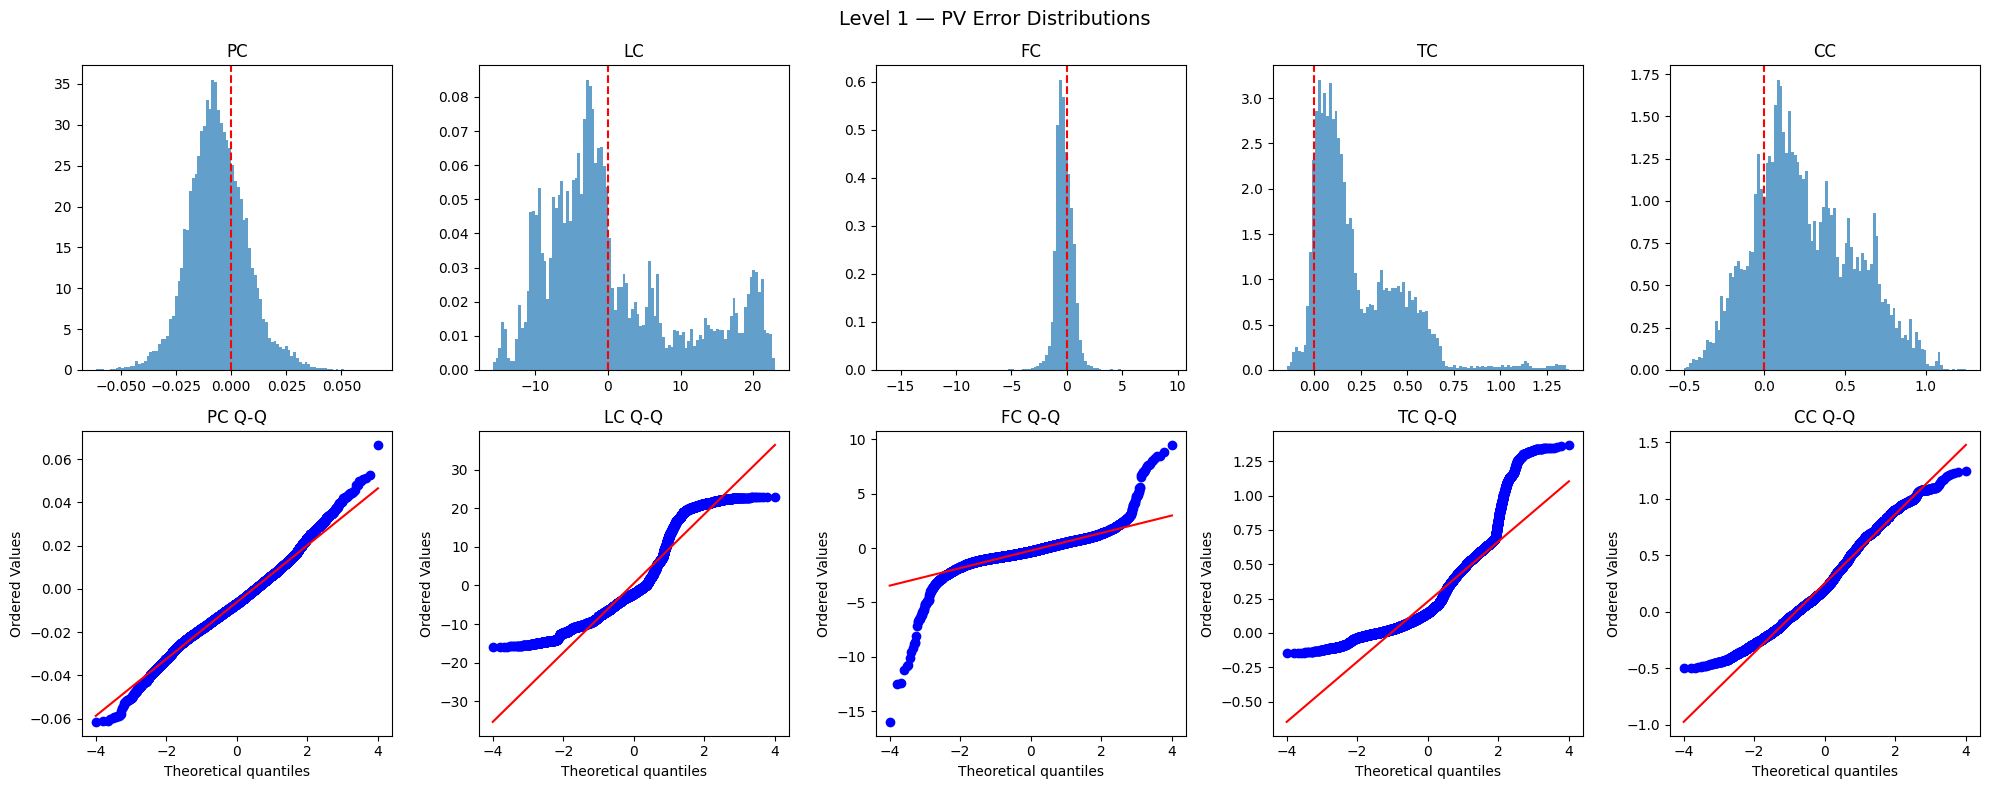


Level 2 — KS test on tracking error:
  PC: KS=0.0596 ✓
  LC: KS=0.2154 ⚠
  FC: KS=0.0668 ✓
  TC: KS=0.1566 ⚠
  CC: KS=0.1214 ⚠


In [10]:
print("=" * 60)
print("LEVEL 1 & 2 VALIDATION")
print("=" * 60)

# Run multiple rollout windows at best horizon for distribution analysis
H = CONFIG.rollout_horizon
n_win = min(12, (len(df_val) - CONFIG.seq_len - H - 1) // H)

all_preds, all_acts = [], []
for wi in range(n_win):
    start = CONFIG.seq_len + wi * H
    pp, _, ap, _ = closed_loop_rollout_gru(df_val, start, H)
    if pp is not None:
        all_preds.append(pp); all_acts.append(ap)

all_preds = np.vstack(all_preds)
all_acts = np.vstack(all_acts)

# Error distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Level 1 — PV Error Distributions', fontsize=14)
for i, c in enumerate(PV_COLS):
    ln = [k for k,l in LOOPS.items() if l.pv==c][0]
    err = all_acts[:,i] - all_preds[:,i]
    axes[0,i].hist(err, bins=100, density=True, alpha=0.7)
    axes[0,i].set_title(f'{ln}'); axes[0,i].axvline(0, color='r', linestyle='--')
    probplot(err, dist="norm", plot=axes[1,i])
    axes[1,i].set_title(f'{ln} Q-Q')
plt.tight_layout(); plt.show()

# KS test on tracking error
print("\nLevel 2 — KS test on tracking error:")
mw = CONFIG.seq_len
for ln, lp in LOOPS.items():
    pi = PV_COLS.index(lp.pv)
    sp = df_val[lp.sp].iloc[mw:mw+len(all_acts)].values[:len(all_acts)]
    real_err = sp - all_acts[:, pi]
    synth_err = sp - all_preds[:, pi]
    ks, p = ks_2samp(real_err[:5000], synth_err[:5000])
    print(f"  {ln}: KS={ks:.4f} {'✓' if ks<0.1 else '⚠'}")

## Cell 11 — HMM Setpoint Generator

In [11]:
class SPGenerator:
    def __init__(self): self.params = {}
    def fit(self, df, loops):
        for ln, lp in loops.items():
            sp = df[lp.sp].values; r = sp.max()-sp.min()
            if r < 1e-10: self.params[ln] = {'type':'steady','val':sp[0]}; continue
            ci = np.where(np.abs(np.diff(sp)) > r*0.01)[0]
            if len(ci)<5: self.params[ln] = {'type':'steady','val':np.mean(sp)}; continue
            dw = np.diff(np.concatenate([[0],ci])); tv = sp[ci+1]
            self.params[ln] = {'type':'trans','vals':tv,'dw':dw,'dw_m':np.mean(dw),'dw_s':np.std(dw),
                'sp_min':lp.sp_range[0],'sp_max':lp.sp_range[1],'sp_m':np.mean(tv),'sp_s':np.std(tv),
                'n':len(ci),'rate':len(ci)/(len(sp)/3600)}
    def generate(self, dur, rng=None):
        if rng is None: rng = np.random.default_rng(42)
        out = {}
        for ln, p in self.params.items():
            s = np.zeros(dur)
            if p['type']=='steady': s[:]=p['val']
            else:
                t,v = 0, rng.uniform(p['sp_min'],p['sp_max'])
                while t<dur:
                    d = max(30,int(rng.normal(p['dw_m'],p['dw_s']))); s[t:min(t+d,dur)]=v
                    v = np.clip(rng.normal(p['sp_m'],p['sp_s']),p['sp_min'],p['sp_max']); t+=d
            out[ln]=s
        return out
    def summary(self):
        for ln,p in self.params.items():
            if p['type']=='steady': print(f"  {ln}: STEADY={p['val']:.3f}")
            else: print(f"  {ln}: {p['n']} trans ({p['rate']:.1f}/hr), SP={p['sp_m']:.2f}±{p['sp_s']:.2f}")

spg = SPGenerator(); spg.fit(df_fit, LOOPS)
print("HMM Setpoint Statistics:"); spg.summary()

HMM Setpoint Statistics:
  PC: 652 trans (3.4/hr), SP=0.12±0.03
  LC: 680 trans (3.5/hr), SP=350.79±21.02
  FC: 622 trans (3.2/hr), SP=996.31±22.41
  TC: 176 trans (0.9/hr), SP=26.46±0.75
  CC: 67 trans (0.3/hr), SP=27.56±0.21


## Cell 12 — Attack Injection Framework

In [12]:
class AttackType(Enum):
    BIAS="bias"; RAMP="ramp"; FREEZE="freeze"; STEP="step"; NOISE="noise"; SCALE="scale"

@dataclass
class AttackSpec:
    target_loop: str; injection_point: str; attack_type: AttackType
    onset: int; duration: int; magnitude: float=0.0; rate: float=0.0
    noise_std: float=0.0; description: str=""
    def is_active(self, t): return self.onset <= t < self.onset + self.duration
    def apply_val(self, val, t):
        if not self.is_active(t): return val
        rt = t - self.onset
        if self.attack_type==AttackType.BIAS: return val+self.magnitude
        elif self.attack_type==AttackType.RAMP: return val+self.rate*rt
        elif self.attack_type==AttackType.STEP: return self.magnitude
        elif self.attack_type==AttackType.NOISE: return val+np.random.normal(0,self.noise_std)
        elif self.attack_type==AttackType.SCALE: return val*self.magnitude
        return val

def run_attack_sim_gru(df, start_idx, duration, attacks):
    """Attack simulation using GRU models with hidden state."""
    loop_names = list(LOOPS.keys())
    warmup = CONFIG.seq_len

    if start_idx + warmup + duration + 1 >= len(df):
        print("Not enough data for attack sim")
        return pd.DataFrame()

    # --- Warmup hidden states ---
    ctrl_hiddens = {}
    for ln in ['PC', 'LC', 'FC', 'TC']:
        model = ctrl_models[ln]
        sc = ctrl_scalers[ln]['scaler']
        cols = ctrl_scalers[ln]['cols']
        wd = sc.transform(df[cols].iloc[start_idx:start_idx+warmup].values)
        wx = torch.tensor(wd[:, :-1], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            _, h = model.gru(wx)
        ctrl_hiddens[ln] = h

    wp = plant_scaler.transform(df[plant_all_cols].iloc[start_idx:start_idx+warmup].values)
    plant_h = None
    with torch.no_grad():
        for t in range(warmup):
            x_t = torch.tensor(wp[t], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(DEVICE)
            _, plant_h = plant_model.gru(x_t, plant_h)

    pv_offset = n_plant_in
    current_pvs_raw = df[PV_COLS].iloc[start_idx + warmup].values.astype(np.float32).copy()

    # Organize attacks
    spa = {ln:[a for a in attacks if a.target_loop==ln and a.injection_point=='SP'] for ln in loop_names}
    cva = {ln:[a for a in attacks if a.target_loop==ln and a.injection_point=='CV'] for ln in loop_names}
    pva = {ln:[a for a in attacks if a.target_loop==ln and a.injection_point=='PV'] for ln in loop_names}
    frozen = {}
    frozen_cvs = {}  # for CV freeze attacks
    records = []

    for t in range(duration):
        abs_t = start_idx + warmup + t
        if abs_t + 1 >= len(df): break

        rec = {'time': t}; active = False
        rsp = {ln: df[LOOPS[ln].sp].iloc[abs_t] for ln in loop_names}

        # SP attacks
        ssp = {}
        for ln in loop_names:
            v = rsp[ln]
            for a in spa[ln]:
                if a.is_active(t): v=a.apply_val(v,t); active=True
            ssp[ln] = v

        # PV spoofing
        pvs = {}
        for ln, lp in LOOPS.items():
            pr = current_pvs_raw[PV_COLS.index(lp.pv)]
            ps = pr
            for a in pva[ln]:
                if a.is_active(t):
                    if a.attack_type==AttackType.FREEZE:
                        if ln not in frozen: frozen[ln]=pr
                        ps = frozen[ln]
                    else: ps = a.apply_val(pr, t)
                    active = True
                elif ln in frozen:
                    del frozen[ln]
            pvs[ln] = ps

        # Controllers
        icv = {}
        for ln in ['PC', 'LC', 'FC', 'TC']:
            lp = LOOPS[ln]
            sc = ctrl_scalers[ln]['scaler']
            input_raw = [ssp[ln], pvs[ln]]
            if lp.cv_fb: input_raw.append(df[lp.cv_fb].iloc[abs_t])
            input_scaled = (np.array(input_raw) - sc.mean_[:-1]) / sc.scale_[:-1]
            x_t = torch.tensor(input_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                cv_s, ctrl_hiddens[ln] = ctrl_models[ln].step(x_t, ctrl_hiddens[ln])
            cv_raw = cv_s.item() * sc.scale_[-1] + sc.mean_[-1]
            cv_raw = np.clip(cv_raw, *CV_LIMITS[ln])
            icv[ln] = cv_raw

        # CC
        cc_in = cc_scaler.transform(np.array([[pvs['CC'], ssp['CC']]]))[0]
        cc_t = torch.tensor(cc_in, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            icv['CC'] = np.clip(cc_model.predict(cc_t).item(), *CV_LIMITS['CC'])

        # CV attacks
        acv = {}
        for ln in loop_names:
            v = icv[ln]
            for a in cva[ln]:
                if a.is_active(t):
                    if a.attack_type==AttackType.FREEZE:
                        if ln not in frozen_cvs: frozen_cvs[ln] = v
                        v = frozen_cvs[ln]
                    else:
                        v = a.apply_val(v, t)
                    active = True
                elif ln in frozen_cvs:
                    del frozen_cvs[ln]
            acv[ln] = v

        # Plant step
        plant_row = df[plant_all_cols].iloc[abs_t].values.copy()
        for ln in loop_names:
            cv_col = LOOPS[ln].cv
            if cv_col in PLANT_IN_COLS:
                plant_row[PLANT_IN_COLS.index(cv_col)] = acv[ln]

        full_scaled = plant_scaler.transform(plant_row.reshape(1,-1))[0]
        cv_scaled_t = torch.tensor(full_scaled[:n_plant_in], dtype=torch.float32).unsqueeze(0).to(DEVICE)

        pv_cur_scaled = (current_pvs_raw - plant_scaler.mean_[pv_offset:]) / plant_scaler.scale_[pv_offset:]
        pv_cur_t = torch.tensor(pv_cur_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pv_pred_scaled, plant_h = plant_model.step(cv_scaled_t, pv_cur_t, plant_h)

        npv = pv_pred_scaled.cpu().numpy()[0] * plant_scaler.scale_[pv_offset:] + plant_scaler.mean_[pv_offset:]
        for i, c in enumerate(PV_COLS):
            npv[i] = np.clip(npv[i], *PV_LIMITS[c])

        for ln in loop_names:
            pi = PV_COLS.index(LOOPS[ln].pv)
            rec.update({
                f'{ln}_SP_real': rsp[ln], f'{ln}_SP_seen': ssp[ln],
                f'{ln}_CV_intended': icv[ln], f'{ln}_CV_actual': acv[ln],
                f'{ln}_PV_real': npv[pi], f'{ln}_PV_seen': pvs[ln]
            })
        rec['attack_label'] = 1 if active else 0
        records.append(rec)
        current_pvs_raw = npv.copy()

    return pd.DataFrame(records)

print("✓ GRU attack injection framework ready")

✓ GRU attack injection framework ready


## Cell 13 — Attack Sanity Checks

ATTACK SANITY CHECKS

  SP Bias LC +20...

  CV Freeze FC...

  PV Freeze PC...

  Combined LC...


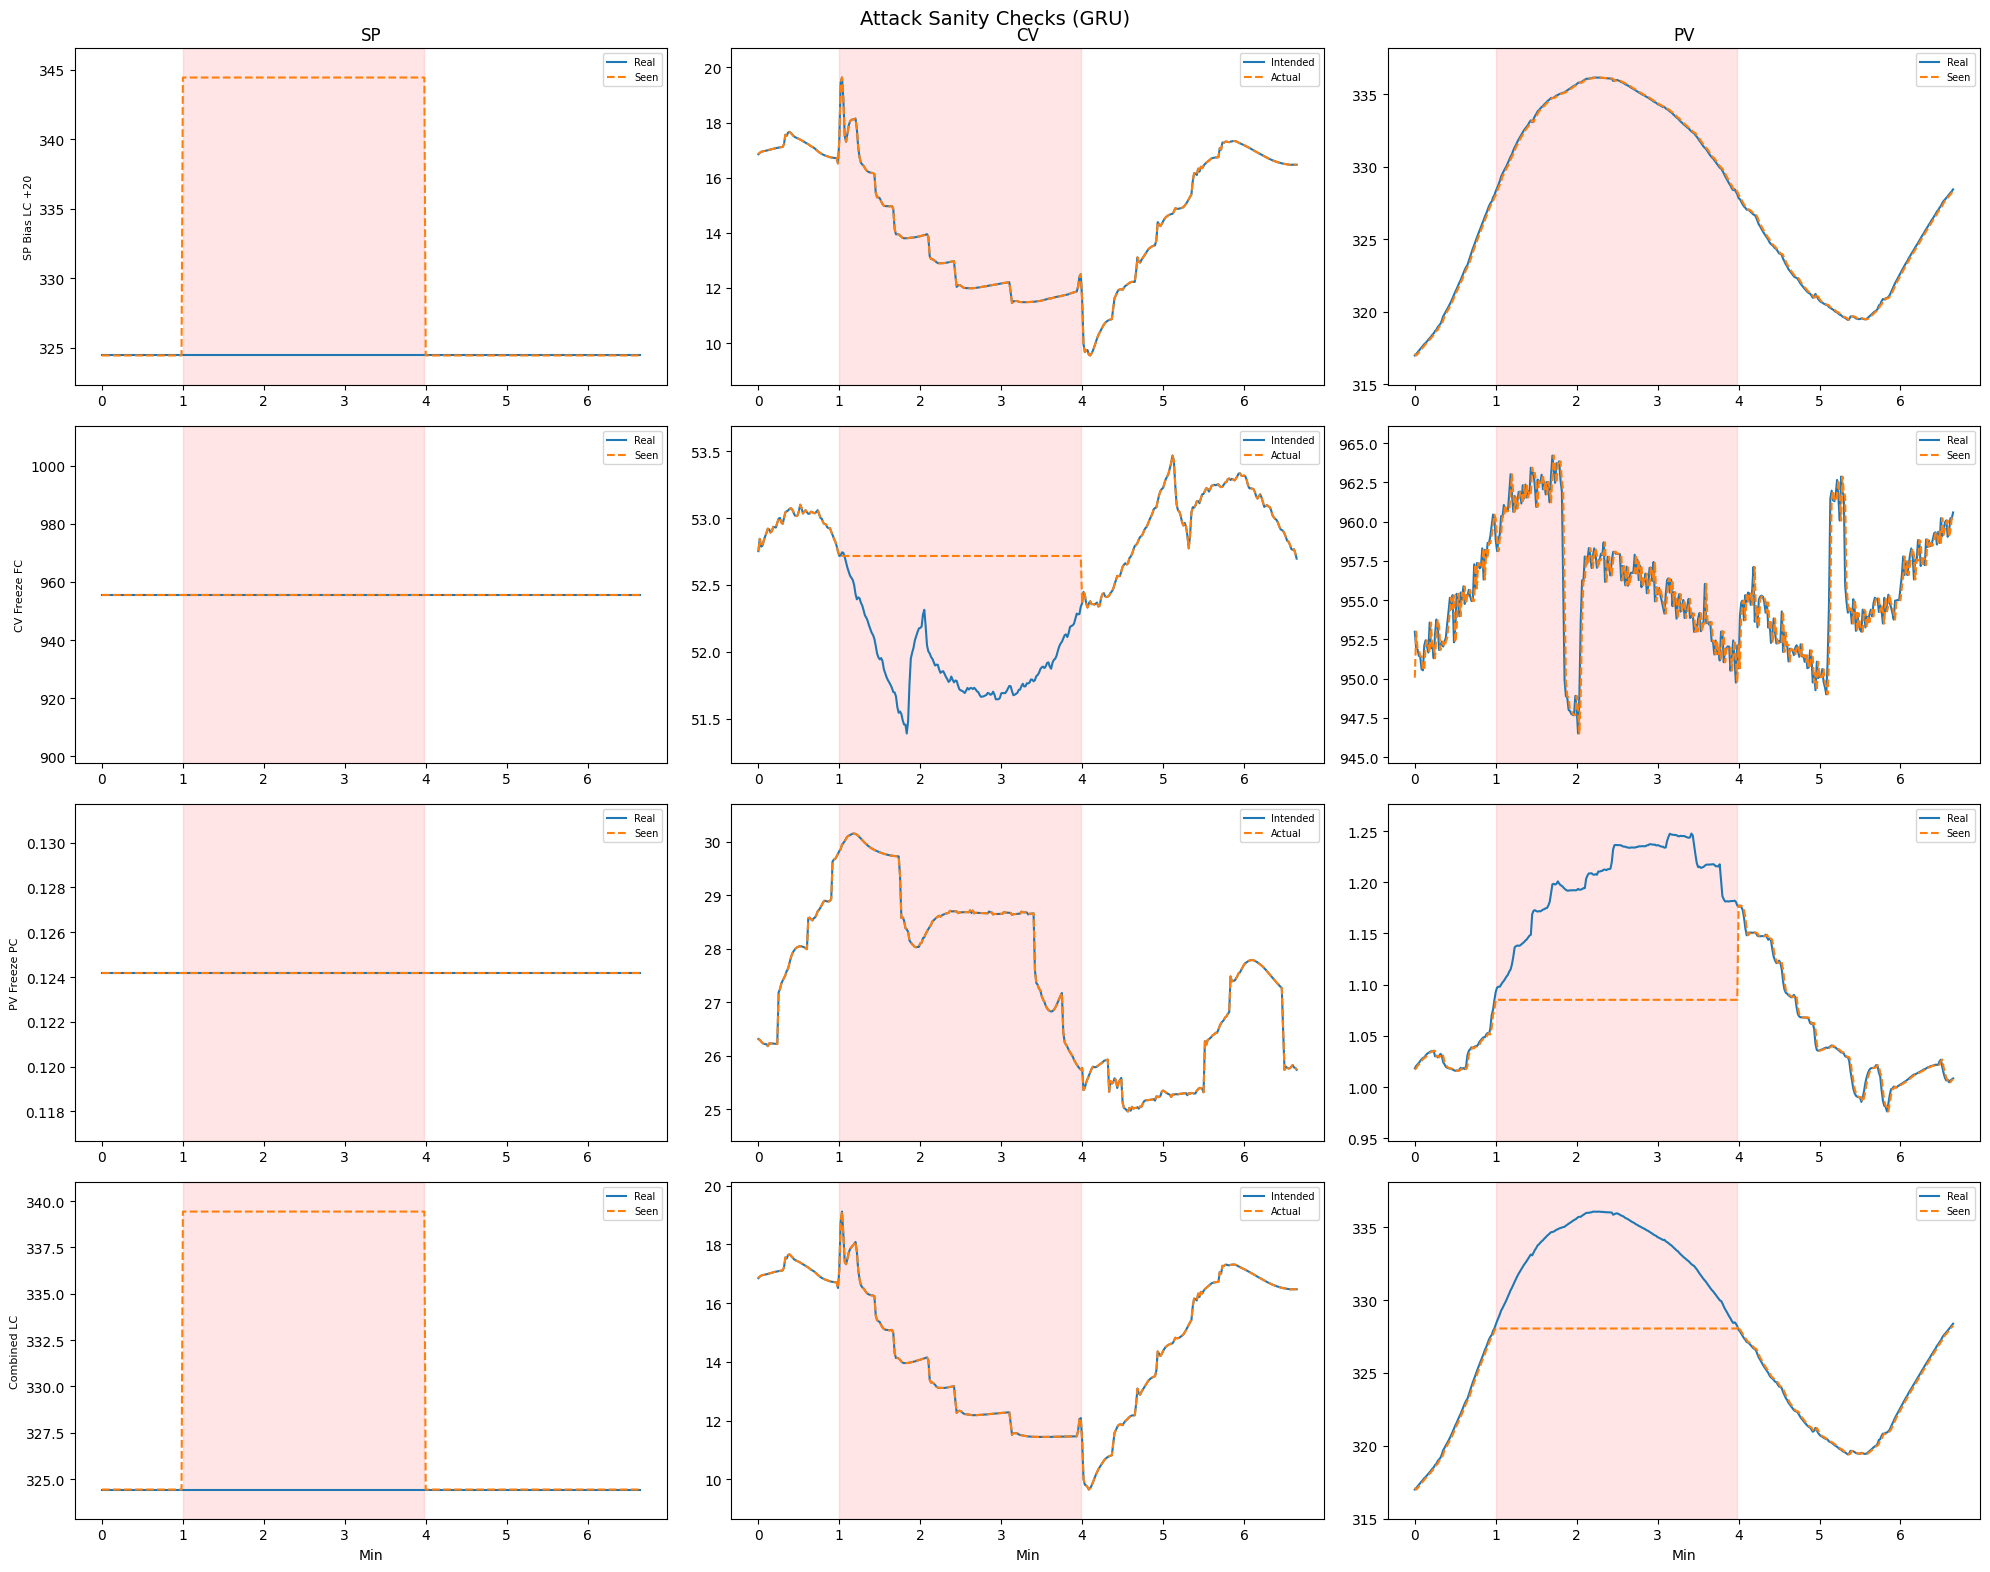


✓ Attack catalog: 6 scenarios


In [13]:
print("=" * 60)
print("ATTACK SANITY CHECKS")
print("=" * 60)

asi = CONFIG.seq_len + 1000
adur = min(CONFIG.rollout_horizon, 400)
atk_onset = 60
atk_dur = 180

tests = [
    ("SP Bias LC +20", [AttackSpec('LC','SP',AttackType.BIAS,atk_onset,atk_dur,magnitude=20)], 'LC'),
    ("CV Freeze FC", [AttackSpec('FC','CV',AttackType.FREEZE,atk_onset,atk_dur)], 'FC'),
    ("PV Freeze PC", [AttackSpec('PC','PV',AttackType.FREEZE,atk_onset,atk_dur)], 'PC'),
    ("Combined LC", [AttackSpec('LC','SP',AttackType.BIAS,atk_onset,atk_dur,magnitude=15),
                     AttackSpec('LC','PV',AttackType.FREEZE,atk_onset,atk_dur)], 'LC'),
]

fig, axes = plt.subplots(len(tests), 3, figsize=(20, 4*len(tests)))
fig.suptitle('Attack Sanity Checks (GRU)', fontsize=14)

for row, (title, specs, ln) in enumerate(tests):
    print(f"\n  {title}...")
    da = run_attack_sim_gru(df_val, asi, adur, specs)
    if len(da) == 0: continue
    t = da['time'].values / 60

    for ci, (cs, ls) in enumerate([
        ([f'{ln}_SP_real',f'{ln}_SP_seen'], ['Real','Seen']),
        ([f'{ln}_CV_intended',f'{ln}_CV_actual'], ['Intended','Actual']),
        ([f'{ln}_PV_real',f'{ln}_PV_seen'], ['Real','Seen'])
    ]):
        ax = axes[row, ci]
        ax.plot(t, da[cs[0]], label=ls[0])
        ax.plot(t, da[cs[1]], label=ls[1], linestyle='--')
        ax.fill_between(t, 0, 1, where=da['attack_label']==1,
                        alpha=0.1, color='red', transform=ax.get_xaxis_transform())
        ax.legend(fontsize=7)
        if row == 0: ax.set_title(['SP','CV','PV'][ci])
    axes[row, 0].set_ylabel(title, fontsize=8)

for ax in axes[-1]: ax.set_xlabel('Min')
plt.tight_layout(); plt.show()

# Attack catalog
HAI_CATALOG = {
    'AP01': AttackSpec('PC','SP',AttackType.BIAS,60,180,magnitude=0.5),
    'AP14': AttackSpec('LC','SP',AttackType.BIAS,60,180,magnitude=20),
    'AP11': AttackSpec('FC','CV',AttackType.BIAS,60,180,magnitude=3),
    'AP16': AttackSpec('LC','CV',AttackType.BIAS,60,180,magnitude=3),
    'AP19': AttackSpec('TC','CV',AttackType.BIAS,60,180,magnitude=5),
    'AP23': AttackSpec('CC','CV',AttackType.BIAS,60,180,magnitude=5),
}
print(f"\n✓ Attack catalog: {len(HAI_CATALOG)} scenarios")

## Cell 14 — Summary Dashboard

In [14]:
print("=" * 60)
print("A100 SURROGATE MODEL — SUMMARY")
print("=" * 60)

print(f"\nArchitecture: GRU Controller (per-loop) + GRU Plant (MIMO) + CC Classifier-Regressor")
print(f"Controller: hidden={CONFIG.ctrl_hidden}, layers={CONFIG.ctrl_layers}")
print(f"Plant: hidden={CONFIG.plant_hidden}, layers={CONFIG.plant_layers}")
print(f"Seq length: {CONFIG.seq_len}s, Scheduled sampling: {CONFIG.ss_max_ratio*100:.0f}%")

print(f"\n--- Controller Results ---")
for ln, nrmse in ctrl_gate_results.items():
    print(f"  {'✓' if nrmse<0.10 else '✗'} {ln}: NRMSE={nrmse:.4f}")

print(f"\n--- Closed-Loop Results (multi-horizon) ---")
for H, results in sorted(gate_results.items()):
    all_pass = all(r['passed'] for r in results.values())
    status = '✓' if all_pass else '✗'
    worst = max(r['mean'] for r in results.values())
    print(f"  {status} {H/60:.0f} min: worst NRMSE={worst:.4f}")

print(f"\nBest passing horizon: {CONFIG.rollout_horizon/60:.0f} min")
prev_horizon = 5  # NARX version
improvement = CONFIG.rollout_horizon / 300 if CONFIG.rollout_horizon > 300 else 1.0
print(f"Improvement over NARX: {improvement:.1f}× rollout horizon")

print(f"\n--- Improvements over NARX version ---")
print(f"  GRU hidden state: reduced collinearity, better long-horizon stability")
print(f"  Scheduled sampling: trained for rollout robustness")
print(f"  CC classifier-regressor: handles binary switching")
print(f"  HAIEnd integration: {len([c for c in HAIEND_COLS if c not in constant_cols])} internal signals as plant auxiliaries")
print(f"  x1001_15_ASSIGN_OUT: kept as plant auxiliary (PC scale bridge)")

print(f"\n--- Capabilities ---")
print(f"  ✓ SP/CV/PV attack injection at any loop")
print(f"  ✓ {len(HAI_CATALOG)} HAI attack scenarios mapped")
print(f"  ✓ GRU hidden state warmup for contextual initialization")

print(f"\n--- Limitations ---")
print(f"  P1 only, no P2/P3/P4")
print(f"  HAIEnd signals as auxiliary inputs only, not predicted as outputs")
print(f"  CV feedback uses real data during attack sim (approximation)")
print(f"  Fidelity degrades for perturbations > 2σ outside training envelope")

A100 SURROGATE MODEL — SUMMARY

Architecture: GRU Controller (per-loop) + GRU Plant (MIMO) + CC Classifier-Regressor
Controller: hidden=64, layers=2
Plant: hidden=256, layers=2
Seq length: 300s, Scheduled sampling: 50%

--- Controller Results ---
  ✓ PC: NRMSE=0.0151
  ✓ LC: NRMSE=0.0065
  ✓ FC: NRMSE=0.0042
  ✓ TC: NRMSE=0.0057
  ✗ CC: NRMSE=0.3063

--- Closed-Loop Results (multi-horizon) ---
  ✓ 5 min: worst NRMSE=0.0044
  ✓ 10 min: worst NRMSE=0.0065
  ✓ 15 min: worst NRMSE=0.0087
  ✓ 30 min: worst NRMSE=0.0144

Best passing horizon: 30 min
Improvement over NARX: 6.0× rollout horizon

--- Improvements over NARX version ---
  GRU hidden state: reduced collinearity, better long-horizon stability
  Scheduled sampling: trained for rollout robustness
  CC classifier-regressor: handles binary switching
  HAIEnd integration: 36 internal signals as plant auxiliaries
  x1001_15_ASSIGN_OUT: kept as plant auxiliary (PC scale bridge)

--- Capabilities ---
  ✓ SP/CV/PV attack injection at any lo